# Who Actually Pays the Airline Competition Premium?
## A data-mining investigation of US airfares, 1993–2024

Source:
Kaggle – US Airline Flight Routes and Fares
https://www.kaggle.com/datasets/bhavikjikadara/us-airline-flight-routes-and-fares-1993-2024

## Overview and Motivation

This project studies how airline competition affects ticket prices in the U.S. domestic airline market.

The motivation for this project came from a very personal experience. During spring break, I was trying to book flights out of College Station, and I noticed that tickets were much more expensive compared to flying out of nearby airports like Houston or Austin. Since College Station (Easterwood Airport) is relatively small and seems to be dominated by a single major airline, it made me curious.

It raised a simple question:

**Do we actually pay more when one airline dominates a route or an airport?**

At first, this feels like an obvious “yes.” Less competition should mean higher prices. But instead of relying on intuition, I wanted to test this idea using real data and see if it consistently holds across the U.S. airline network.

To answer this, I use U.S. airline market data from 1993 to 2024 and analyze factors like route distance, passenger volume, market concentration, and carrier type. As the project develops, the story becomes more nuanced. The simple idea that "monopoly route = higher fare" does not fully hold. In fact, many monopoly routes appear cheaper on average because they are often operated by low-cost carriers.

This leads to a deeper and more refined question:

**Is the fare premium actually driven by legacy-carrier dominance at certain airports (also known as fortress hubs), rather than simple route-level monopoly?**

This notebook walks through that investigation step by step - from data cleaning and baseline modeling to market structure analysis and airport-level insights — and concludes with a clearer understanding of where and why passengers may end up paying more.

## Notebook Roadmap

This notebook is organized as a curated project story:

1. **Data Cleaning and Preparation**  
   I clean the airline fare data, remove invalid records, and create useful route-level features.

2. **Baseline Fare Modeling**  
   I first model fares using basic factors like distance, passenger volume, year, and seasonality.

3. **Market Concentration Analysis**  
   I test whether routes dominated by one airline have higher fares.

4. **Carrier-Type Diagnosis**  
   I separate legacy carriers from low-cost carriers to understand why monopoly routes do not always mean higher fares.

5. **Airport Graph and Fortress Hub Analysis**  
   I use graph-based analysis to identify airports where legacy carriers have strong dominance.

6. **Time Trend and Case Study**  
   I study how the legacy-carrier premium changes over time and compare DFW with MDW as a concrete example.

7. **Final Conclusions**  
   I summarize what the results mean, what the limitations are, and what I learned from the project.

## Phase 0 - Setup and Data Loading

Imports and data load. We reuse the cleaning choices locked in during Checkpoints 1 and 2 - no re-derivation here.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
RNG = np.random.default_rng(42)

In [ ]:
# Load data
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/Sem4/Data Mining/project/airline_data.csv"
df = pd.read_csv(file_path, low_memory=False)

# Keep a working copy
raw = df.copy()
print("Raw shape:", raw.shape)
raw.head(2)

Mounted at /content/drive
Raw shape: (245955, 23)


,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.430,G4,1.000,81.430,G4,1.000,81.430,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.930,DL,0.466,219.980,UA,0.119,154.110,NaN,NaN,202131013515304ABETPA


## The Hook - Two Routes, One Mystery

Before doing the full analysis, I wanted to start with a simple example from the data.

The code below searches for two routes from the most recent year that are very similar in basic travel characteristics: same year and quarter, similar distance, and comparable passenger volume. The main difference is competition structure. One route is close to a monopoly route, while the other is more competitive.

This example is not meant to prove the project’s conclusion by itself. It is only a starting point that shows why the question is interesting.

If two similar routes can have very different fares, then it is worth asking whether airline dominance is one of the reasons behind that difference.

In [ ]:
# Standardize column names for the whole notebook
raw.columns = [c.strip().lower() for c in raw.columns]

# Minimal working frame for the hook search — full cleaning comes in Phase 1
hook_df = raw.loc[
    (raw["fare"] > 0)
    & (raw["large_ms"].between(0, 1))
    & (raw["lf_ms"].between(0, 1))
    & (raw["city1"] != raw["city2"]),
    ["year", "quarter", "city1", "city2", "airport_1", "airport_2",
     "nsmiles", "passengers", "fare", "carrier_lg", "large_ms", "carrier_low", "lf_ms"]
].copy()

# Pick the most recent complete year for a clean comparison
latest_year = hook_df["year"].max()
recent = hook_df[hook_df["year"] == latest_year].copy()

# Find a monopoly route (one carrier >= 90% share) and a competitive route
# with SAME distance bucket and SIMILAR passenger volume, but different fare.
recent["dist_bucket"] = (recent["nsmiles"] // 50).astype(int) * 50

monopoly = recent[recent["large_ms"] >= 0.90].copy()
competitive = recent[recent["large_ms"] <= 0.50].copy()

joined = monopoly.merge(
    competitive,
    on=["dist_bucket", "quarter"],
    suffixes=("_mono", "_comp"),
)
joined["pax_ratio"] = joined[["passengers_mono", "passengers_comp"]].min(axis=1) \
                     / joined[["passengers_mono", "passengers_comp"]].max(axis=1)
joined["fare_gap"] = joined["fare_mono"] - joined["fare_comp"]
joined = joined[joined["pax_ratio"] > 0.7]          # comparable demand
joined = joined[joined["fare_gap"] > 30]            # material fare gap

best = joined.sort_values("fare_gap", ascending=False).head(1)

hook_table = pd.DataFrame({
    "route":          [f"{best['city1_mono'].iat[0]} ↔ {best['city2_mono'].iat[0]}",
                       f"{best['city1_comp'].iat[0]} ↔ {best['city2_comp'].iat[0]}"],
    "year_quarter":   [f"{int(best['year_mono'].iat[0])} Q{int(best['quarter'].iat[0])}",
                       f"{int(best['year_comp'].iat[0])} Q{int(best['quarter'].iat[0])}"],
    "distance (mi)":  [int(best["nsmiles_mono"].iat[0]), int(best["nsmiles_comp"].iat[0])],
    "passengers":     [int(best["passengers_mono"].iat[0]), int(best["passengers_comp"].iat[0])],
    "avg fare ($)":   [round(best["fare_mono"].iat[0], 2),  round(best["fare_comp"].iat[0], 2)],
    "dominant carrier": [best["carrier_lg_mono"].iat[0],    best["carrier_lg_comp"].iat[0]],
    "dominant share": [f"{best['large_ms_mono'].iat[0]:.0%}", f"{best['large_ms_comp'].iat[0]:.0%}"],
    "label":          ["Monopoly route", "Competitive route"],
}).set_index("label")

fare_delta = round(best["fare_gap"].iat[0], 2)
print(f"Fare gap between these two comparable routes: ${fare_delta}")
hook_table

Fare gap between these two comparable routes: $315.61


,route,year_quarter,distance (mi),passengers,avg fare ($),dominant carrier,dominant share
label,,,,,,,
Monopoly route,"Jackson, WY ↔ New York City, NY (Metropolitan ...",2024 Q1,1894,200,572.400,UA,93%
Competitive route,"Albuquerque, NM ↔ New York City, NY (Metropoli...",2024 Q1,1861,151,256.790,WN,38%


### Initial Observation

The selected example shows two routes that are similar in quarter, distance, and passenger volume, but the monopoly route has a much higher average fare.

In this specific pair, the fare gap is about **$315.61**, which is large enough to raise the main question of this project:

**Is this just one unusual example, or do airline-dominated markets generally lead to higher fares?**

At this point, I treat the example only as motivation. A single comparison cannot prove a pattern because there may be other differences between the routes, such as airport type, traveler mix, carrier strategy, or regional demand. The rest of the notebook tests this question more systematically using the full dataset.

**Note:** We assume passenger counts are a proxy for demand, and distance buckets approximate route similarity.

## Phase 1 - Data Cleaning and Preparation

The main cleaning steps are:

1. Convert all column names to lowercase for consistency.
2. Remove self-routes where the origin and destination cities are the same.
3. Remove rows with non-positive fares, since those are not meaningful ticket prices.
4. Keep only valid market share values between 0 and 1.
5. Drop rows missing important fields such as fare, distance, passengers, year, quarter, carrier, market share, airport, or city.
6. Create an undirected route key so that A → B and B → A are treated as the same route.
7. Convert year and quarter into integers.
8. Keep only rows with at least one passenger to avoid invalid or extremely noisy observations.

One important choice is that I do **not** remove high fare outliers. Since the project is specifically about whether airline dominance is connected to unusually high fares, removing extreme fares too early could hide the very pattern I am trying to study.


#### Assumptions and Tradeoffs

- I assume rows with missing core fields cannot support reliable fare or competition analysis, so they are removed.
- I treat routes as undirected because the project focuses on market-level fare patterns, not directional pricing differences.
- I keep high fare values because they may be meaningful for the research question, even though they could add some noise.
- I only remove clearly invalid passenger counts rather than aggressively filtering small markets, because small airports are important to this project’s motivation.


In [ ]:
df = raw.copy()

# 1 — already lowercase
# 2, 3 — drop invalid rows
df = df[(df["fare"] > 0) & (df["city1"] != df["city2"])]
df = df[df["large_ms"].between(0, 1) & df["lf_ms"].between(0, 1)]

# 4 — drop missing core fields
core = ["fare", "nsmiles", "passengers", "year", "quarter",
        "carrier_lg", "large_ms", "carrier_low", "lf_ms",
        "airport_1", "airport_2", "city1", "city2"]
df = df.dropna(subset=core).copy()

# 5 — undirected route
df["route"] = df.apply(
    lambda r: " ↔ ".join(sorted([r["city1"], r["city2"]])), axis=1
)

# 6 — types & sanity
df["year"] = df["year"].astype(int)
df["quarter"] = df["quarter"].astype(int)
df["passengers"] = df["passengers"].astype(float)
df = df[df["passengers"] >= 1]

print("Cleaned shape:", df.shape)
print("Year range  :", df["year"].min(), "→", df["year"].max())
print("Quarters    :", sorted(df["quarter"].unique()))
print("Unique routes :", df["route"].nunique())
print("Unique airports:", pd.unique(df[["airport_1", "airport_2"]].values.ravel()).shape[0])
print("Unique carriers (dominant):", df["carrier_lg"].nunique())

Cleaned shape: (237985, 24)
Year range  : 1993 → 2024
Quarters    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique routes : 1266
Unique airports: 212
Unique carriers (dominant): 64


**Observation.** The cleaned dataset retains the bulk of the original rows (around 238,000 rows), spans the full 1993–2024 range, and contains a few hundred airports (around 212) connected by a few thousand(around 1266) undirected routes. The new dataset is still large and broad enough for analysis.

## Phase 2 - Baseline Fare Model

Before testing whether airline competition matters, I first need a baseline model for airfare.

The main question in this phase is:

**Can obvious factors like distance, passenger demand, year, and seasonality already explain most of the variation in fares?**

This step is important because if these basic factors already explain fares well, then market structure may not add much value. But if a large part of fare variation remains unexplained, then it is worth testing whether airline dominance helps explain the remaining differences.

I start with a simple distance-only model because longer flights usually cost more. Then I build a stronger baseline by adding passenger volume, year effects, and quarter effects.

#### Assumptions and Tradeoffs

- I assume distance is one of the main cost drivers for airfare.
- I use passenger volume as a rough proxy for demand on a route.
- I include year effects to account for broad changes over time, such as inflation, fuel prices, and industry shifts.
- I include quarter effects to capture seasonal travel patterns.
- This model is not meant to be a perfect fare prediction model. Its purpose is to create a reasonable baseline before adding competition-related variables.

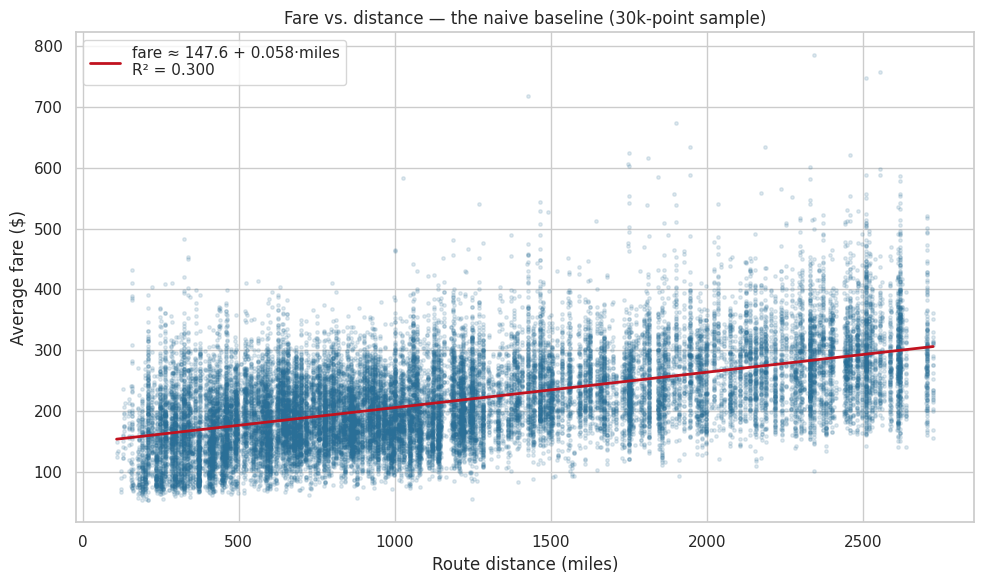

In [ ]:
# Sample for the scatter (plotting 647k dots is illegible)
plot_sample = df.sample(n=30_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_sample["nsmiles"], plot_sample["fare"],
           s=6, alpha=0.15, color="#2a6f97")

# Fitted line
slope, intercept, r_val, p_val, _ = stats.linregress(df["nsmiles"], df["fare"])
x_line = np.linspace(df["nsmiles"].min(), df["nsmiles"].max(), 200)
ax.plot(x_line, intercept + slope * x_line, color="#c1121f", lw=2,
        label=f"fare ≈ {intercept:.1f} + {slope:.3f}·miles\nR² = {r_val**2:.3f}")

ax.set_xlabel("Route distance (miles)")
ax.set_ylabel("Average fare ($)")
ax.set_title("Fare vs. distance — the naive baseline (30k-point sample)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Distance-Only Observation

The scatter plot shows a clear upward trend: longer routes generally have higher average fares, which matches intuition.

However, the spread is very large. Even for routes with similar distance, fares can differ by several hundred dollars. This means distance matters, but it is not enough to explain airline pricing by itself.

The distance-only model gives an R² of about **0.30**, meaning distance explains around 30% of the variation in fares. That is useful, but a lot of variation still remains unexplained.

In [ ]:
# Model M1: fare ~ distance (closed form via statsmodels for CI output)
m1 = smf.ols("fare ~ nsmiles", data=df).fit()
print("=== Model M1: fare ~ nsmiles ===")
print(f"R²       : {m1.rsquared:.4f}")
print(f"Adj R²   : {m1.rsquared_adj:.4f}")
print(f"Nobs     : {int(m1.nobs):,}")
print(f"β(miles) : ${m1.params['nsmiles']:.4f} per mile (95% CI "
      f"${m1.conf_int().loc['nsmiles', 0]:.4f} – ${m1.conf_int().loc['nsmiles', 1]:.4f})")

=== Model M1: fare ~ nsmiles ===
R²       : 0.3002
Adj R²   : 0.3002
Nobs     : 237,985
β(miles) : $0.0582 per mile (95% CI $0.0579 – $0.0586)


In [ ]:
# Model M2: add demand + macro (log passengers + year + quarter fixed effects)
df_m = df.copy()
df_m["log_passengers"] = np.log(df_m["passengers"])
df_m["year_c"]    = df_m["year"].astype("category")
df_m["quarter_c"] = df_m["quarter"].astype("category")

m2 = smf.ols(
    "fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c)",
    data=df_m,
).fit()

print("=== Model M2: fare ~ distance + log(passengers) + year + quarter ===")
print(f"R²      : {m2.rsquared:.4f}")
print(f"Adj R²  : {m2.rsquared_adj:.4f}")
print(f"ΔR² vs M1: {m2.rsquared - m1.rsquared:+.4f}")

=== Model M2: fare ~ distance + log(passengers) + year + quarter ===
R²      : 0.4412
Adj R²  : 0.4412
ΔR² vs M1: +0.1410


### Baseline Model Interpretation

The first model only uses route distance and explains about **30%** of fare variation.

The second model adds passenger volume, year, and quarter. This improves the R² from about **0.30 to 0.44**, which is a meaningful improvement. This tells us that demand, time trends, and seasonality do matter.

However, more than half of the fare variation is still unexplained. This is important because it leaves room for other structural factors, such as airline competition, carrier type, and airport dominance.

So, the baseline model does not answer the full question, but it gives a fair starting point for the next phase.

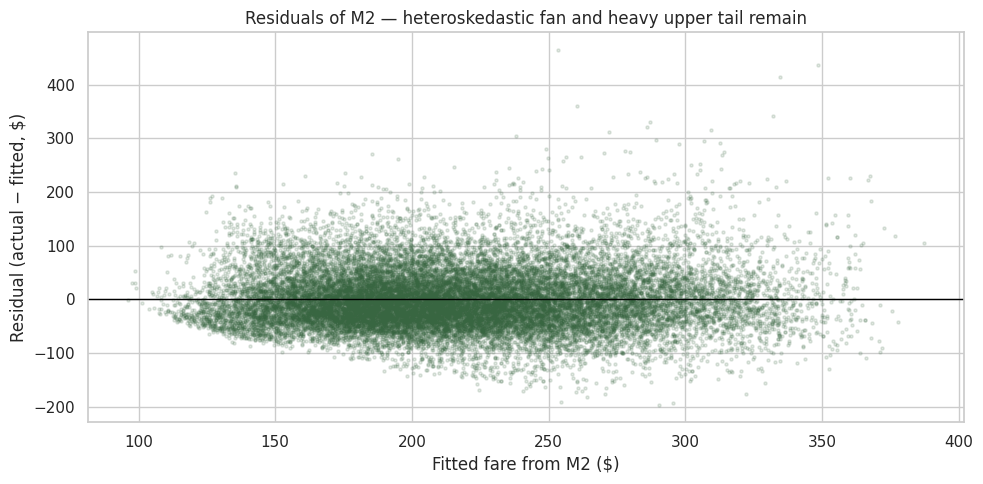

Mean |residual|  : $42.01
Std  residual    : $55.55
95th pctile |res|: $111.11


In [ ]:
# Residual diagnostic for M2 — is there systematic structure left?
sample_idx = df_m.sample(n=25_000, random_state=42).index
resid = m2.resid.loc[sample_idx]
fitted = m2.fittedvalues.loc[sample_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(fitted, resid, s=5, alpha=0.15, color="#386641")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Fitted fare from M2 ($)")
ax.set_ylabel("Residual (actual − fitted, $)")
ax.set_title("Residuals of M2 — heteroskedastic fan and heavy upper tail remain")
plt.tight_layout()
plt.show()

# Summary of residual magnitudes
print(f"Mean |residual|  : ${m2.resid.abs().mean():.2f}")
print(f"Std  residual    : ${m2.resid.std():.2f}")
print(f"95th pctile |res|: ${m2.resid.abs().quantile(0.95):.2f}")

### Residual Diagnostic

The residual plot shows the difference between the actual fare and the fare predicted by the baseline model.

Ideally, residuals would be randomly scattered around zero. Here, the residuals still show a wide spread, especially at higher predicted fares. The average absolute residual is around 42 dollars, and the 95th percentile absolute residual is about 111 dollars.

This means that even after controlling for distance, passenger volume, year, and quarter, many routes are still much cheaper or much more expensive than the model expects.

### Phase 2 Takeaway

The baseline model confirms that basic factors like distance, demand, year, and seasonality explain part of airfare differences, but not all of them.

This motivates the next step: testing whether market concentration and airline dominance help explain the remaining fare differences.

## Phase 3 - Introducing Market Structure

Now that I have a baseline understanding of fares, I introduce the main competition-related features.

The question in this phase is:

**If routes are grouped by how concentrated they are, do fares visibly differ across those groups?**

This phase is still descriptive. I am not claiming that market concentration causes higher or lower fares yet. The goal is to create useful competition labels and look for early patterns.

I create four market-structure features:

1. **Market concentration**: the dominant carrier’s market share on a route.
2. **Monopoly indicator**: whether the dominant carrier has at least 90% market share.
3. **Carrier overlap**: whether the largest carrier and lowest-fare carrier are the same airline.
4. **HHI proxy**: a simplified concentration index based on available carrier market shares.

I also group routes into four competition tiers:

- **Competitive**: dominant carrier has less than 50% market share
- **Split**: dominant carrier has 50–70% market share
- **Concentrated**: dominant carrier has 70–90% market share
- **Monopoly**: dominant carrier has at least 90% market share


### Assumptions and Tradeoffs

- I use the dominant carrier’s market share as the main signal of route concentration.
- I define monopoly as 90% or higher market share, which is a strict but easy-to-interpret threshold.
- The HHI value is only a proxy because the dataset does not fully break down every carrier’s exact share.
- These features describe market structure, but they do not prove causation by themselves.

In [ ]:
# --- Feature engineering --------------------------------------------------

df["market_concentration"] = df["large_ms"]
df["is_monopoly"]  = (df["large_ms"] >= 0.90).astype(int)
df["carrier_overlap"] = (df["carrier_lg"] == df["carrier_low"]).astype(int)

residual_share = (1 - df["large_ms"] - df["lf_ms"]).clip(lower=0)
df["hhi_proxy"] = df["large_ms"]**2 + df["lf_ms"]**2 + residual_share**2

def _tier(ms):
    if ms >= 0.90: return "Monopoly (≥90%)"
    if ms >= 0.70: return "Concentrated (70–90%)"
    if ms >= 0.50: return "Split (50–70%)"
    return "Competitive (<50%)"

df["competition_tier"] = df["market_concentration"].apply(_tier)
tier_order = ["Competitive (<50%)", "Split (50–70%)", "Concentrated (70–90%)", "Monopoly (≥90%)"]

# Quick counts
df["competition_tier"].value_counts().reindex(tier_order).to_frame("n_routes")

,n_routes
competition_tier,
Competitive (<50%),65371
Split (50–70%),68348
Concentrated (70–90%),53620
Monopoly (≥90%),50646


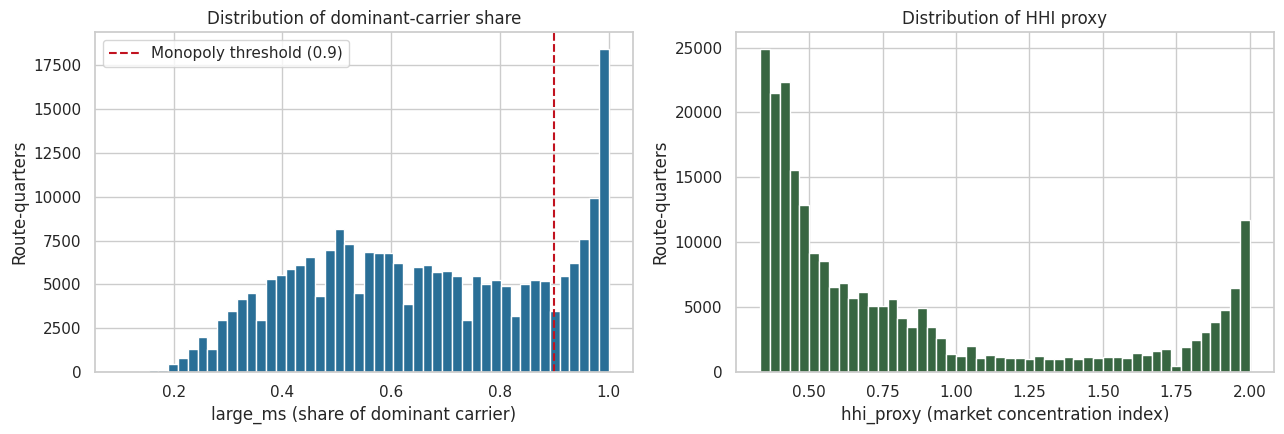

In [ ]:
# Distribution of market_concentration — expect bimodal
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["market_concentration"], bins=50, color="#2a6f97", edgecolor="white")
axes[0].axvline(0.9, color="#c1121f", ls="--", label="Monopoly threshold (0.9)")
axes[0].set_title("Distribution of dominant-carrier share")
axes[0].set_xlabel("large_ms (share of dominant carrier)")
axes[0].set_ylabel("Route-quarters")
axes[0].legend()

axes[1].hist(df["hhi_proxy"], bins=50, color="#386641", edgecolor="white")
axes[1].set_title("Distribution of HHI proxy")
axes[1].set_xlabel("hhi_proxy (market concentration index)")
axes[1].set_ylabel("Route-quarters")
plt.tight_layout(); plt.show()

### Market Structure Distribution

The dominant-carrier share is spread across many levels, but there is also a clear group of routes where one carrier has almost the entire market.

The HHI proxy shows a similar pattern: some routes are fairly competitive, while others are highly concentrated.

This confirms that the dataset has enough variation in market structure to compare competitive, concentrated, and monopoly-like routes.

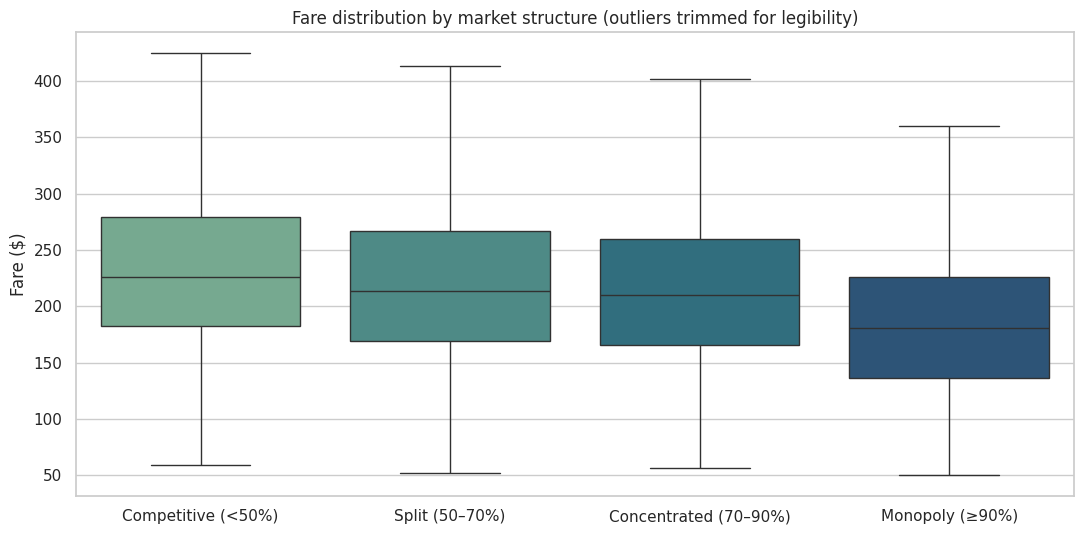

In [ ]:
# Boxplot: fare by competition tier
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=df, x="competition_tier", y="fare", order=tier_order,
            palette="crest", showfliers=False, ax=ax)
ax.set_title("Fare distribution by market structure (outliers trimmed for legibility)")
ax.set_ylabel("Fare ($)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

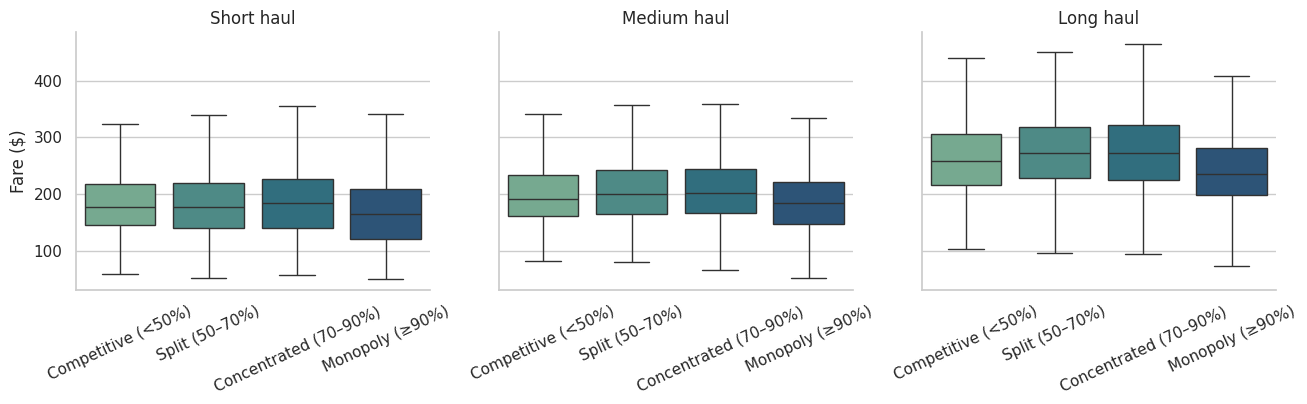

In [ ]:
# Faceted boxplot — same view, split by distance tertile, to make sure
# the pattern isn't purely a short-haul artefact.
df["distance_band"] = pd.qcut(
    df["nsmiles"], q=3, labels=["Short haul", "Medium haul", "Long haul"]
)

g = sns.catplot(
    data=df, kind="box", x="competition_tier", y="fare", col="distance_band",
    order=tier_order, col_order=["Short haul", "Medium haul", "Long haul"],
    palette="crest", showfliers=False, height=4.2, aspect=1.05,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Fare ($)")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

In [ ]:
# Numerical summary table
summary = (df.groupby("competition_tier")
             .agg(n=("fare", "size"),
                  mean_fare=("fare", "mean"),
                  median_fare=("fare", "median"),
                  mean_distance=("nsmiles", "mean"),
                  mean_passengers=("passengers", "mean"))
             .reindex(tier_order))
summary["fare_per_mile"] = summary["mean_fare"] / summary["mean_distance"]
summary.round(2)

,n,mean_fare,median_fare,mean_distance,mean_passengers,fare_per_mile
competition_tier,,,,,,
Competitive (<50%),65371,234.560,225.870,"1,578.540",324.010,0.150
Split (50–70%),68348,221.770,213.960,"1,196.870",374.150,0.190
Concentrated (70–90%),53620,217.810,209.910,"1,070.960",280.840,0.200
Monopoly (≥90%),50646,186.470,180.840,803.400,233.840,0.230


### Raw Fare Pattern

At first, the raw fare comparison gives a surprising result.

Average fare actually decreases as market concentration rises:

- Competitive routes: about 235 dollars
- Monopoly routes: about 186 dollars

The boxplots show the same general pattern: monopoly routes appear cheaper in total fare than competitive routes.

However, the summary table reveals an important issue. Competitive routes are much longer on average, around **1,579 miles**, while monopoly routes average only about **803 miles**. So the lower monopoly fare may simply be because monopoly routes are shorter.

When I look at fare per mile, the pattern changes. Fare per mile increases as concentration rises, from about **0.15 dollars per mile** for competitive routes to about **0.23 dollars per mile** for monopoly routes.

This means the raw total fare comparison is misleading. Monopoly routes look cheaper in total dollars, but they may still be more expensive per mile.

### Phase 3 Takeaway

This phase shows that market structure appears related to fares, but the relationship is not simple.

The raw total fare view suggests monopoly routes are cheaper, while the fare-per-mile view suggests concentrated routes may charge more per unit of distance. Since distance is such a major confounding factor, I need a controlled regression model before making any stronger conclusion.

That is why the next phase adds market concentration variables to the baseline regression model.

## Phase 4 - Quantifying the Monopoly Premium

This phase is the main regression test of the project.

The question here is:

**After controlling for distance, passenger volume, year, and quarter, does market structure still predict fares?**

In Phase 3, the raw comparison was confusing because monopoly routes were much shorter on average. So here I use regression to control for the major factors that already affect fares.

I compare four nested models:

1. **M1:** fare explained only by distance  
2. **M2:** fare explained by distance, passenger volume, year, and quarter  
3. **M3:** M2 plus market concentration  
4. **M4:** M2 plus a monopoly flag and carrier-overlap flag  

The goal is to see whether adding market structure improves the model and whether monopoly routes are actually more expensive after basic controls.

### Assumptions and Tradeoffs

- I assume distance, demand, year, and quarter are important baseline controls.
- I use log(passengers) because passenger volume is highly skewed, and the log version is easier to model.
- I treat year and quarter as categorical controls, not continuous trends.
- The regression identifies association, not perfect causation.
- The monopoly flag is only a simple market-structure measure, so it may hide differences between carrier types.

In [ ]:
# Build the regression frame — reuse M2 setup from Phase 2
reg = df.copy()
reg["log_passengers"] = np.log(reg["passengers"])
reg["year_c"]    = reg["year"].astype("category")
reg["quarter_c"] = reg["quarter"].astype("category")

# Fit all four
m1 = smf.ols("fare ~ nsmiles", data=reg).fit()

m2 = smf.ols("fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c)",
             data=reg).fit()

m3 = smf.ols("fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
             "+ market_concentration", data=reg).fit()

m4 = smf.ols("fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
             "+ is_monopoly + carrier_overlap", data=reg).fit()

summary = pd.DataFrame({
    "Model":       ["M1 — distance only", "M2 — + demand + era",
                    "M3 — + concentration", "M4 — + monopoly flag"],
    "R²":          [m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared],
    "Adj R²":      [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj, m4.rsquared_adj],
    "ΔR² vs M2":   [m1.rsquared - m2.rsquared, 0.0,
                    m3.rsquared - m2.rsquared, m4.rsquared - m2.rsquared],
    "n":           [int(m1.nobs), int(m2.nobs), int(m3.nobs), int(m4.nobs)],
})
summary.round(4)

,Model,R²,Adj R²,ΔR² vs M2,n
0,M1 — distance only,0.300,0.300,-0.141,237985
1,M2 — + demand + era,0.441,0.441,0.000,237985
2,M3 — + concentration,0.444,0.444,0.003,237985
3,M4 — + monopoly flag,0.467,0.467,0.026,237985


In [ ]:
# The headline coefficients with 95% CIs
rows = []
for label, mod, var in [
    ("M3: market_concentration (per +1.0, i.e. 0→100% share)", m3, "market_concentration"),
    ("M3: market_concentration (per +10pp share)",             m3, "market_concentration"),
    ("M4: is_monopoly (monopoly vs non-monopoly, $)",          m4, "is_monopoly"),
    ("M4: carrier_overlap (dominant == cheapest carrier, $)",   m4, "carrier_overlap"),
]:
    b  = mod.params[var]
    lo, hi = mod.conf_int().loc[var].tolist()
    scale = 0.10 if "10pp" in label else 1.0
    rows.append({
        "effect": label,
        "estimate": b * scale,
        "ci_low":   lo * scale,
        "ci_high":  hi * scale,
        "p":        mod.pvalues[var],
    })

headline = pd.DataFrame(rows)
print("=== Headline coefficients (95% CIs) ===")
headline.round(3)

=== Headline coefficients (95% CIs) ===


,effect,estimate,ci_low,ci_high,p
0,"M3: market_concentration (per +1.0, i.e. 0→100...",-18.823,-19.949,-17.697,0.000
1,M3: market_concentration (per +10pp share),-1.882,-1.995,-1.770,0.000
2,"M4: is_monopoly (monopoly vs non-monopoly, $)",-12.612,-13.203,-12.022,0.000
3,M4: carrier_overlap (dominant == cheapest carr...,-19.770,-20.247,-19.293,0.000


### Main Regression Result

Adding market structure does improve the model, but only modestly.

The R² increases from about **0.441** in the baseline model to about **0.467** in the model with monopoly and carrier-overlap features. This means market structure contains useful information, but it is not the only driver of fares.

The surprising result is the direction of the monopoly coefficient.

After controlling for distance, passenger volume, year, and quarter, monopoly routes are estimated to be about **$12.61 cheaper** than non-monopoly routes on average.

This is the opposite of the original expectation. I expected monopoly routes to be more expensive, but the regression suggests that the simple route-level monopoly flag is not capturing market power cleanly.

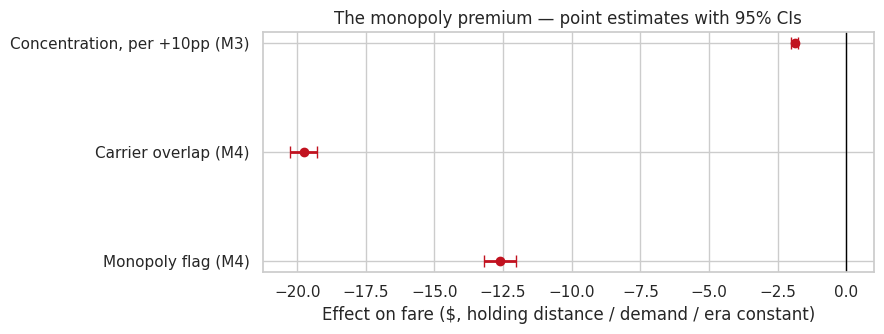

In [ ]:
# Forest-style plot of the two key coefficients
fig, ax = plt.subplots(figsize=(9, 3.5))
labels = ["Monopoly flag (M4)", "Carrier overlap (M4)", "Concentration, per +10pp (M3)"]
vals = [
    (m4.params["is_monopoly"],      *m4.conf_int().loc["is_monopoly"].tolist()),
    (m4.params["carrier_overlap"],  *m4.conf_int().loc["carrier_overlap"].tolist()),
    (m3.params["market_concentration"] * 0.10,
     m3.conf_int().loc["market_concentration", 0] * 0.10,
     m3.conf_int().loc["market_concentration", 1] * 0.10),
]
for i, (est, lo, hi) in enumerate(vals):
    ax.errorbar(est, i, xerr=[[est - lo], [hi - est]], fmt="o",
                color="#c1121f", capsize=4, lw=2)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Effect on fare ($, holding distance / demand / era constant)")
ax.set_title("The monopoly premium — point estimates with 95% CIs")
plt.tight_layout(); plt.show()

In [ ]:
# Robustness 1: log(fare) — coefficient reads as ≈ % premium
reg["log_fare"] = np.log(reg["fare"])
m4_log = smf.ols(
    "log_fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
    "+ is_monopoly + carrier_overlap",
    data=reg,
).fit()
b_mono = m4_log.params["is_monopoly"]
lo, hi = m4_log.conf_int().loc["is_monopoly"].tolist()
print(f"log-linear M4 — is_monopoly β = {b_mono:.4f}  "
      f"→ ≈ {(np.exp(b_mono)-1)*100:.2f}% fare premium  "
      f"(95% CI {(np.exp(lo)-1)*100:.2f}% – {(np.exp(hi)-1)*100:.2f}%)")

log-linear M4 — is_monopoly β = -0.0847  → ≈ -8.12% fare premium  (95% CI -8.37% – -7.86%)


In [ ]:
# Robustness 2: re-fit M4 within each distance band
band_rows = []
for band, sub in reg.groupby("distance_band"):
    m = smf.ols(
        "fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
        "+ is_monopoly + carrier_overlap", data=sub).fit()
    lo, hi = m.conf_int().loc["is_monopoly"].tolist()
    band_rows.append({
        "distance_band": band,
        "n": int(m.nobs),
        "monopoly_premium_$": m.params["is_monopoly"],
        "ci_low":  lo,
        "ci_high": hi,
        "R²": m.rsquared,
    })
pd.DataFrame(band_rows).round(3)

,distance_band,n,monopoly_premium_$,ci_low,ci_high,R²
0,Short haul,79458,-3.510,-4.328,-2.692,0.327
1,Medium haul,79381,-21.622,-22.575,-20.669,0.287
2,Long haul,79146,-25.295,-26.803,-23.787,0.292


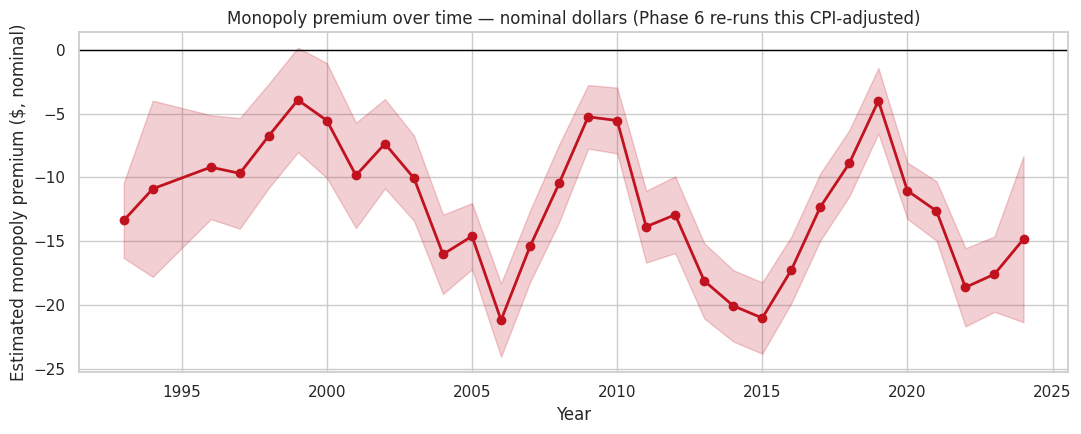

,year,n,premium,lo,hi
23,2017,8043,-12.310,-14.930,-9.690
24,2018,8005,-8.880,-11.470,-6.300
25,2019,7970,-4.010,-6.560,-1.450
26,2020,7221,-11.040,-13.240,-8.830
27,2021,7554,-12.620,-14.940,-10.300
28,2022,7639,-18.590,-21.650,-15.540
29,2023,7650,-17.560,-20.510,-14.620
30,2024,1870,-14.820,-21.320,-8.330


In [ ]:
# Robustness 3: re-fit year by year — preview of Phase 6
year_rows = []
for yr, sub in reg.groupby("year"):
    if sub["is_monopoly"].nunique() < 2 or len(sub) < 500:
        continue
    m = smf.ols(
        "fare ~ nsmiles + log_passengers + C(quarter_c) "
        "+ is_monopoly + carrier_overlap", data=sub).fit()
    lo, hi = m.conf_int().loc["is_monopoly"].tolist()
    year_rows.append({
        "year": int(yr), "n": int(m.nobs),
        "premium": m.params["is_monopoly"], "lo": lo, "hi": hi,
    })
year_df = pd.DataFrame(year_rows)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(year_df["year"], year_df["premium"], marker="o", color="#c1121f", lw=2)
ax.fill_between(year_df["year"], year_df["lo"], year_df["hi"], alpha=0.2, color="#c1121f")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Year"); ax.set_ylabel("Estimated monopoly premium ($, nominal)")
ax.set_title("Monopoly premium over time — nominal dollars (Phase 6 re-runs this CPI-adjusted)")
plt.tight_layout(); plt.show()
year_df.tail(8).round(2)

### Robustness Checks

I run a few checks to see whether the surprising result is just a modeling artifact.

The log-fare model also shows a negative monopoly effect, suggesting that monopoly routes are around **8% cheaper** on average after controls.

When I split routes into distance bands, the monopoly coefficient remains negative across short-haul, medium-haul, and long-haul routes. The effect is smaller for short routes and larger for long routes.

The year-by-year model also shows that the monopoly coefficient is negative in most years.

Together, these checks suggest that the result is not just caused by one model specification. The negative coefficient appears consistently enough that it needs explanation.

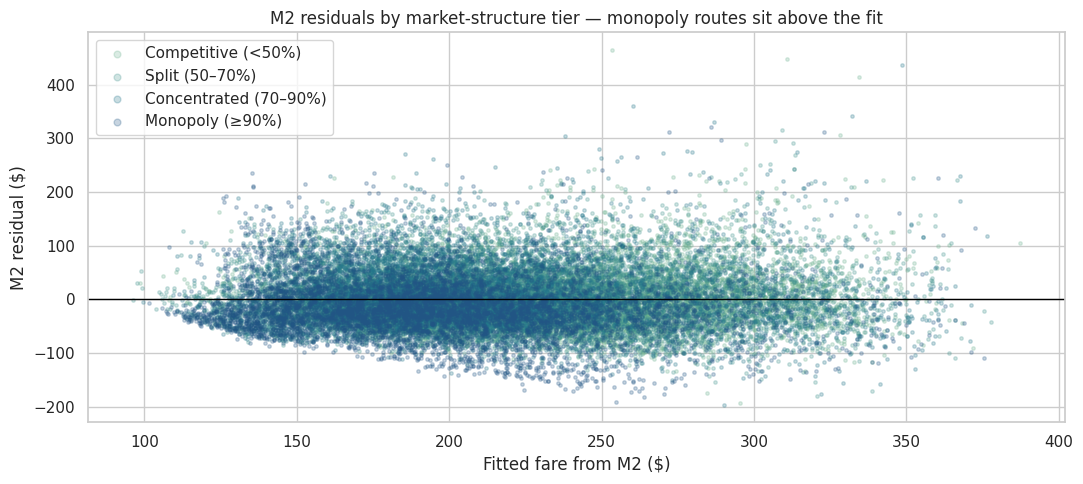

Mean M2 residual by tier ($):
competition_tier
Competitive (<50%)       -0.260
Split (50–70%)            4.960
Concentrated (70–90%)     7.260
Monopoly (≥90%)         -14.040
Name: _r, dtype: float64


In [ ]:
# Residuals from M2 colored by tier — shows monopoly routes systematically sit above the fit
sample_idx = reg.sample(n=30_000, random_state=42).index
res = m2.resid.loc[sample_idx]
fit = m2.fittedvalues.loc[sample_idx]
tier = reg.loc[sample_idx, "competition_tier"]

fig, ax = plt.subplots(figsize=(11, 5))
palette = dict(zip(tier_order, sns.color_palette("crest", len(tier_order))))
for t in tier_order:
    mask = (tier == t).values
    ax.scatter(fit[mask], res[mask], s=6, alpha=0.25,
               color=palette[t], label=t)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Fitted fare from M2 ($)")
ax.set_ylabel("M2 residual ($)")
ax.set_title("M2 residuals by market-structure tier — monopoly routes sit above the fit")
ax.legend(markerscale=2, loc="upper left")
plt.tight_layout(); plt.show()

print("Mean M2 residual by tier ($):")
print(reg.assign(_r=m2.resid).groupby("competition_tier")["_r"].mean().reindex(tier_order).round(2))

### The Twist

This is the first major turning point in the project.

The original hypothesis was:

**If one airline dominates a route, fares should be higher.**

But the regression result says something different:

**At the route level, monopoly routes appear cheaper after controls.**

This does not necessarily mean monopoly power lowers prices. A more likely explanation is that the monopoly variable is mixing together different types of routes and carriers.

For example, many monopoly routes may be short, thin markets served by low-cost carriers such as Southwest, Spirit, Frontier, Allegiant, or JetBlue. These airlines may dominate certain routes while still charging lower fares because their business model is different.

On the other hand, competitive routes in this dataset may include many large, business-heavy routes between major airports, where fares are naturally higher.

So the monopoly flag may not be measuring only “market power.” It may also be picking up **carrier identity, route type, and airport structure**.

### Phase 4 Takeaway

This phase shows that simple route-level monopoly is not enough to explain airline pricing.

The result is actually useful because it challenges the first assumption of the project. Instead of concluding that “monopoly always means higher fares,” the analysis suggests a more careful question:

**When does airline dominance lead to higher fares, and does the answer depend on the type of carrier?**

The next phase investigates this by separating legacy carriers from low-cost carriers.

## Phase 5 - Diagnosing the Monopoly Result: Who Runs the Monopoly Routes?

Phase 4 gave a surprising result: monopoly routes appeared cheaper after controls.

So the next question is:

**Is the monopoly result really about market power, or is it partly about the type of airline operating the route?**

To test this, I classify each dominant carrier into one of four groups:

1. **Legacy carriers**: large traditional network airlines such as American, Delta, United, and their predecessors.
2. **ULCC / low-cost carriers**: airlines such as Southwest, JetBlue, Spirit, Frontier, Allegiant, and similar carriers.
3. **Regional carriers**: smaller regional airlines or affiliates.
4. **Other carriers**: carriers that do not clearly fit into the above groups.

This helps separate two very different situations:

- A legacy airline dominating a major hub route
- A low-cost airline dominating a cheaper, thinner route

Both may look like “monopoly” in the data, but they may have very different pricing behavior.

### Assumptions and Tradeoffs

- I classify carriers manually based on common industry categories and carrier codes.
- Some older or less common carrier codes may be simplified into broader groups.
- This classification is not perfect, but it is useful for separating legacy-carrier behavior from low-cost-carrier behavior.
- This phase is still mostly descriptive. It explains why the earlier regression may have produced the opposite sign.

In [ ]:
# --- Carrier type mapping ------------------------------------------------
# IATA codes grouped from the DOT Form 41 carrier table and industry usage.

LEGACY   = {"AA", "DL", "UA", "US", "NW", "CO", "HP", "TW", "AS"}
ULCC     = {"NK", "F9", "G4", "WN", "B6", "VX", "SY"}
REGIONAL = {"9E", "OO", "YV", "OH", "EV", "MQ", "XE", "OE", "RP", "QX", "YX",
            "EM", "ZW", "YV", "C5", "CP", "ZK", "PT"}

def classify_carrier(c):
    if not isinstance(c, str):      return "Other"
    if c in LEGACY:                  return "Legacy"
    if c in ULCC:                    return "ULCC"
    if c in REGIONAL:                return "Regional"
    return "Other"

df["carrier_type_lg"]  = df["carrier_lg"].map(classify_carrier)
df["carrier_type_low"] = df["carrier_low"].map(classify_carrier)

# Sanity: how many routes per carrier type?
print(df["carrier_type_lg"].value_counts())
print()
# Top carriers in each bucket — spot-check the mapping is sensible
for t in ["Legacy", "ULCC", "Regional", "Other"]:
    top = df.loc[df["carrier_type_lg"] == t, "carrier_lg"].value_counts().head(5)
    print(f"{t:9s} — top carriers: {dict(top)}")

carrier_type_lg
Legacy      161389
ULCC         69360
Other         6248
Regional       988
Name: count, dtype: int64

Legacy    — top carriers: {'AA': np.int64(44273), 'DL': np.int64(33016), 'UA': np.int64(29371), 'US': np.int64(24665), 'CO': np.int64(13768)}
ULCC      — top carriers: {'WN': np.int64(58509), 'B6': np.int64(6105), 'G4': np.int64(2127), 'NK': np.int64(1263), 'F9': np.int64(1101)}
Regional  — top carriers: {'YX': np.int64(929), 'YV': np.int64(16), 'ZW': np.int64(15), 'RP': np.int64(12), 'OE': np.int64(7)}
Other     — top carriers: {'FL': np.int64(3089), 'TZ': np.int64(1251), 'JI': np.int64(309), 'DH': np.int64(183), 'RU': np.int64(182)}


In [ ]:
# Cross-tab: % of each competition tier that is held by each carrier type.
# Row = carrier type, column = tier, values = column percentages.
tier_order = ["Competitive (<50%)", "Split (50–70%)",
              "Concentrated (70–90%)", "Monopoly (≥90%)"]

ct = (pd.crosstab(df["carrier_type_lg"], df["competition_tier"], normalize="columns")
        .mul(100).round(1))
ct = ct[tier_order]
print("Column percentages — what share of each tier does each carrier type run?")
ct

Column percentages — what share of each tier does each carrier type run?


competition_tier,Competitive (<50%),Split (50–70%),Concentrated (70–90%),Monopoly (≥90%)
carrier_type_lg,,,,
Legacy,77.700,72.700,67.100,49.300
Other,2.200,2.700,2.400,3.300
Regional,0.500,0.500,0.500,0.100
ULCC,19.600,24.100,30.000,47.300


### Carrier Composition Result

The carrier-type breakdown explains a major part of the earlier surprise.

Competitive routes are mostly operated by legacy carriers. About **78%** of competitive route observations have a legacy carrier as the dominant carrier.

But monopoly routes are much more mixed. Only about **49%** of monopoly route observations are legacy-dominated, while about **47%** are dominated by ULCC or low-cost carriers.

This matters because low-cost carriers generally have lower fare structures. So when many monopoly routes are operated by low-cost carriers, the average fare for monopoly routes can look lower even if some legacy monopoly routes are expensive.

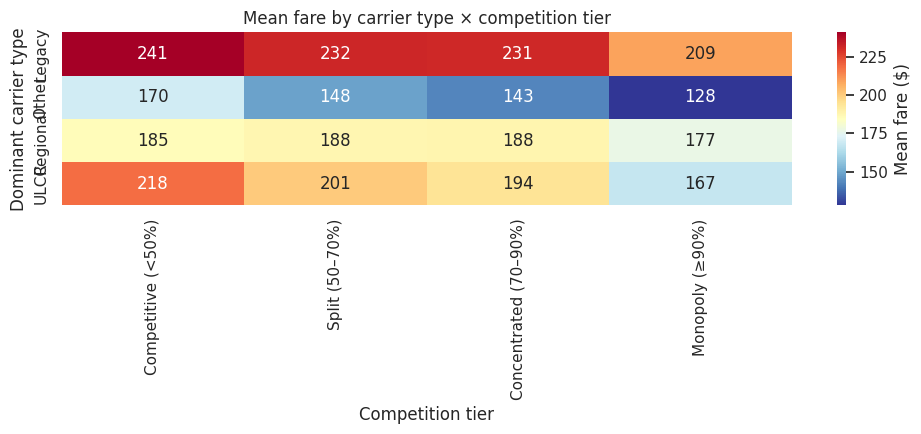

competition_tier,Competitive (<50%),Split (50–70%),Concentrated (70–90%),Monopoly (≥90%)
carrier_type_lg,,,,
Legacy,240.900,231.800,231.300,208.700
Other,170.000,148.400,142.900,128.000
Regional,185.400,187.600,188.200,176.900
ULCC,218.000,200.500,194.300,167.400


In [ ]:
# Mean fare by (carrier type × competition tier) as a heatmap.
pivot = (df.groupby(["carrier_type_lg", "competition_tier"])["fare"]
           .mean().unstack()[tier_order])

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlBu_r",
            cbar_kws={"label": "Mean fare ($)"}, ax=ax)
ax.set_title("Mean fare by carrier type × competition tier")
ax.set_xlabel("Competition tier"); ax.set_ylabel("Dominant carrier type")
plt.tight_layout(); plt.show()

pivot.round(1)

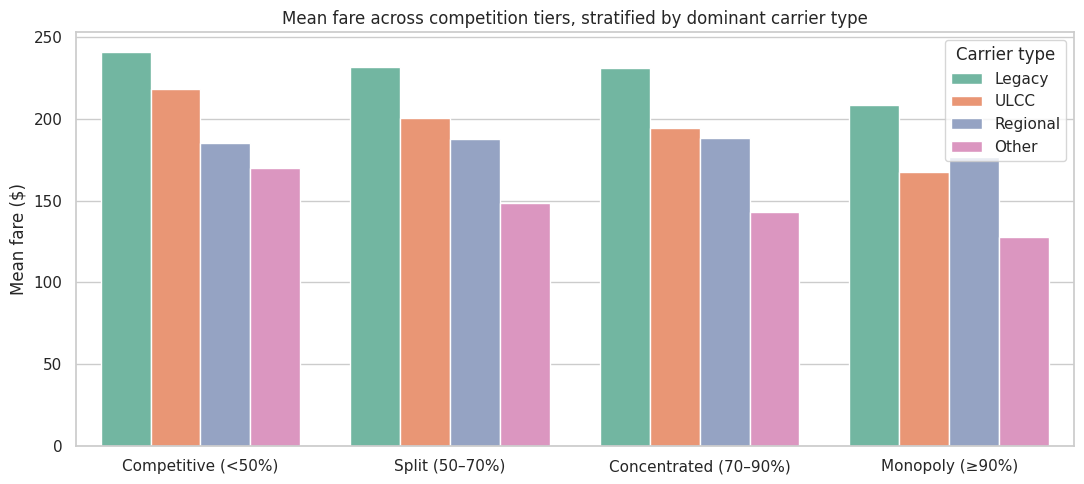

In [ ]:
# Grouped bar view of the same pattern — easier to read the within-type trend.
plot_df = (df.groupby(["competition_tier", "carrier_type_lg"])["fare"]
             .mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="competition_tier", y="fare",
            hue="carrier_type_lg", order=tier_order,
            hue_order=["Legacy", "ULCC", "Regional", "Other"],
            palette="Set2", ax=ax)
ax.set_title("Mean fare across competition tiers, stratified by dominant carrier type")
ax.set_ylabel("Mean fare ($)"); ax.set_xlabel("")
ax.legend(title="Carrier type")
plt.tight_layout(); plt.show()

### Fare Pattern by Carrier Type

The heatmap and bar chart show that carrier type changes the story.

Within almost every competition tier, legacy carriers have higher average fares than ULCC or low-cost carriers.

At the same time, the monopoly tier has a much higher share of ULCC routes than the competitive tier. This means the monopoly category is not only measuring market concentration. It is also partly capturing **who the dominant carrier is**.

This is the key diagnosis: the negative monopoly result from Phase 4 is likely a composition effect.

In simpler terms, the model was mixing together different kinds of monopoly routes:
- some legacy-dominated routes that may have higher fares
- many low-cost-carrier-dominated routes that tend to have lower fares

Because the low-cost monopoly routes are so common, they pull the overall monopoly coefficient downward.

### Phase 5 Takeaway

This phase shows that the route-level monopoly variable is not clean enough by itself.

A monopoly route operated by a low-cost carrier is very different from a monopoly route operated by a legacy carrier. Treating both as the same can hide the real pricing pattern.

So the important lesson is:

**Monopoly status alone does not explain fare behavior. Carrier type matters.**

The next phase tests this more directly by re-running the monopoly model separately within carrier types.

## Phase 6 - Re-running the Model Within Each Carrier Type

In Phase 5, I found that monopoly routes are not all the same. Many monopoly routes are operated by low-cost carriers, while others are operated by legacy carriers.

So the question in this phase is:

**If I compare monopoly and non-monopoly routes within the same carrier type, does the monopoly effect change?**

To test this, I use two approaches:

1. **Stratified regression**  
   I run the same regression separately for legacy carriers and ULCC / low-cost carriers.

2. **Interaction model**  
   I run one combined model with an interaction between carrier type and monopoly status. This checks whether the monopoly effect differs across carrier groups.

### Assumptions and Tradeoffs

- I assume carrier type is an important factor in pricing strategy.
- I keep the same controls as before: distance, passenger volume, year, and quarter.
- Regional carriers are skipped in the stratified regression because the sample is too small for a reliable estimate.
- This is still an association-based model, not a causal claim.

In [ ]:
# Prep a regression frame that carries carrier type.
reg_c = reg.copy()
reg_c["carrier_type_lg"] = df.loc[reg_c.index, "carrier_type_lg"]

# --- A. Stratified M4 --------------------------------------------------
stratified = {}
rows = []
for ct in ["Legacy", "ULCC", "Regional"]:
    sub = reg_c[reg_c["carrier_type_lg"] == ct]
    if len(sub) < 1000 or sub["is_monopoly"].nunique() < 2:
        print(f"{ct}: skipped (n={len(sub)}, monopoly unique={sub['is_monopoly'].nunique()})")
        continue
    m = smf.ols(
        "fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
        "+ is_monopoly + carrier_overlap",
        data=sub,
    ).fit()
    stratified[ct] = m
    lo, hi = m.conf_int().loc["is_monopoly"].tolist()
    rows.append({
        "carrier_type": ct,
        "n":            int(m.nobs),
        "is_monopoly_$": m.params["is_monopoly"],
        "ci_low":       lo,
        "ci_high":      hi,
        "p":            m.pvalues["is_monopoly"],
        "R²":           m.rsquared,
    })

stratified_df = pd.DataFrame(rows)
print("=== Stratified M4 ===")
stratified_df.round(3)

Regional: skipped (n=988, monopoly unique=2)
=== Stratified M4 ===


,carrier_type,n,is_monopoly_$,ci_low,ci_high,p,R²
0,Legacy,161389,0.856,-0.005,1.718,0.051,0.421
1,ULCC,69360,-14.603,-15.201,-14.004,0.000,0.698


### Stratified Regression Result

This is the key test of the carrier-type diagnosis.

For **legacy carriers**, the monopoly coefficient is very close to zero: about **+$0.86**. This means that within legacy carriers, route-level monopoly does not clearly increase fares in this pooled model.

For **ULCC / low-cost carriers**, the monopoly coefficient is strongly negative: about **−$14.60**. This means that low-cost carrier monopoly routes are still cheaper on average after controls.

The log-fare version shows a similar pattern:
- Legacy monopoly routes are about **1% cheaper**
- ULCC monopoly routes are about **9% cheaper**

So the original negative monopoly result is mainly driven by low-cost-carrier routes.

In [ ]:
# --- B. Unified interaction model ---------------------------------------
reg_int = reg_c[reg_c["carrier_type_lg"].isin(["Legacy", "ULCC", "Regional"])].copy()
reg_int["ct"] = reg_int["carrier_type_lg"].astype("category")

m_int = smf.ols(
    "fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
    "+ C(ct) * is_monopoly + carrier_overlap",
    data=reg_int,
).fit()

# Pull the interaction terms — these tell us how is_monopoly differs across types
interaction_terms = [ix for ix in m_int.params.index if "is_monopoly" in ix]
int_table = pd.DataFrame({
    "term":     interaction_terms,
    "estimate": [m_int.params[t]           for t in interaction_terms],
    "ci_low":   [m_int.conf_int().loc[t, 0] for t in interaction_terms],
    "ci_high":  [m_int.conf_int().loc[t, 1] for t in interaction_terms],
    "p":        [m_int.pvalues[t]          for t in interaction_terms],
})
print("=== Interaction model — is_monopoly-related coefficients ===")
int_table.round(3)

=== Interaction model — is_monopoly-related coefficients ===


,term,estimate,ci_low,ci_high,p
0,is_monopoly,-1.074,-1.836,-0.312,0.006
1,C(ct)[T.Regional]:is_monopoly,-15.221,-31.399,0.956,0.065
2,C(ct)[T.ULCC]:is_monopoly,-10.645,-11.729,-9.560,0.000


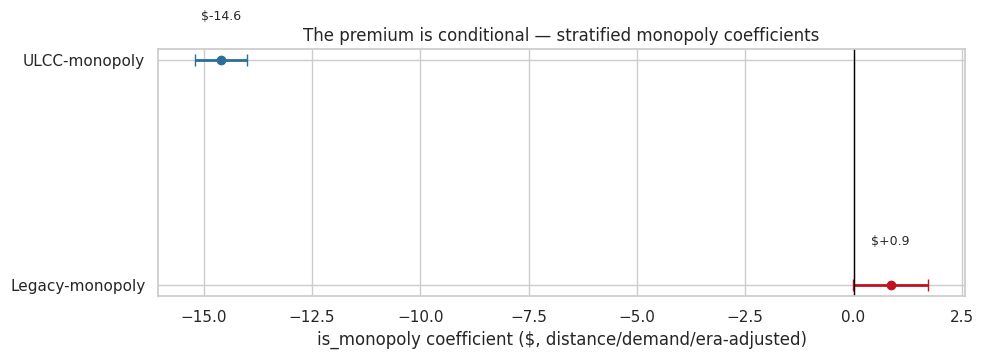

In [ ]:
# Forest plot — stratified is_monopoly coefficients
fig, ax = plt.subplots(figsize=(10, 3.8))

labels = [r["carrier_type"] for r in rows]
ests   = [r["is_monopoly_$"] for r in rows]
los    = [r["ci_low"]   for r in rows]
his    = [r["ci_high"]  for r in rows]

for i, (lbl, e, lo, hi) in enumerate(zip(labels, ests, los, his)):
    color = "#c1121f" if e > 0 else "#2a6f97"
    ax.errorbar(e, i, xerr=[[e-lo],[hi-e]], fmt="o", color=color, capsize=4, lw=2)
    ax.text(e, i + 0.18, f"${e:+.1f}", ha="center", fontsize=9)

ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(len(labels))); ax.set_yticklabels([f"{l}-monopoly" for l in labels])
ax.set_xlabel("is_monopoly coefficient ($, distance/demand/era-adjusted)")
ax.set_title("The premium is conditional — stratified monopoly coefficients")
plt.tight_layout(); plt.show()

In [ ]:
# Log-linear version of the stratified result — coefficients read as ≈ % premium
log_rows = []
for ct, m_base in stratified.items():
    sub = reg_c[reg_c["carrier_type_lg"] == ct].copy()
    sub["log_fare"] = np.log(sub["fare"])
    m = smf.ols(
        "log_fare ~ nsmiles + log_passengers + C(year_c) + C(quarter_c) "
        "+ is_monopoly + carrier_overlap",
        data=sub,
    ).fit()
    b = m.params["is_monopoly"]
    lo, hi = m.conf_int().loc["is_monopoly"].tolist()
    log_rows.append({
        "carrier_type": ct,
        "n":            int(m.nobs),
        "%_premium":    (np.exp(b)-1)*100,
        "%_ci_low":     (np.exp(lo)-1)*100,
        "%_ci_high":    (np.exp(hi)-1)*100,
    })
log_strat = pd.DataFrame(log_rows)
print("=== Stratified log-linear M4 — percentage premium ===")
log_strat.round(2)

=== Stratified log-linear M4 — percentage premium ===


,carrier_type,n,%_premium,%_ci_low,%_ci_high
0,Legacy,161389,-0.980,-1.350,-0.610
1,ULCC,69360,-8.930,-9.240,-8.630


### Phase 6 Takeaway

This phase shows that the monopoly effect depends strongly on carrier type.

The original idea was that monopoly routes would become more expensive once I separated legacy carriers from low-cost carriers. That did not clearly happen at the route level. Within legacy carriers, the monopoly effect is close to zero, while within ULCC carriers, monopoly routes are clearly cheaper.

This means that simple route-level concentration is still not enough to explain the fare premium.

The better explanation may be that market power operates at a larger level, especially through airport dominance. A legacy carrier may not need to hold 90% of every single route to influence pricing if it already dominates an airport’s overall network.

That leads to the next phase, where I move from route-level analysis to airport-level graph analysis and look for legacy “fortress hubs.”

## Phase 7 - Airport Graph and Fortress Hub Analysis

So far, the route-level results show that simple monopoly status does not fully explain fares.

This phase shifts the analysis from individual routes to airports.

The question here is:

**Is the fare premium concentrated at certain airports where one legacy carrier dominates the overall airport network?**

To study this, I build an airport graph:

- **Nodes** represent airports.
- **Edges** represent routes between airports.
- **Edge weights** use passenger volume and average fare.

Then, for each airport, I calculate a **legacy fortress score**. This score measures how much of an airport’s outbound route activity is dominated by a single legacy carrier.

A high fortress score means one legacy carrier controls a large share of routes from that airport.

### Assumptions and Tradeoffs

- I treat the airline network as an undirected graph because the focus is on airport-to-airport market structure, not direction-specific pricing.
- I filter out very small airports so that the fortress ranking is not driven by tiny airports with only a few routes.
- I use legacy carrier dominance as the main signal of fortress behavior.
- This graph analysis is mainly structural and descriptive. It helps identify patterns, but it does not prove causation by itself.

In [ ]:
import networkx as nx

# --- Build the graph ---------------------------------------------------
edge_agg = (df.groupby(["airport_1", "airport_2"])
              .agg(passengers=("passengers", "sum"),
                   fare=("fare", "mean"),
                   n_obs=("fare", "size"))
              .reset_index())

G = nx.Graph()
for _, r in edge_agg.iterrows():
    a, b = sorted([r["airport_1"], r["airport_2"]])
    G.add_edge(a, b, passengers=r["passengers"], fare=r["fare"])

print(f"Graph: {G.number_of_nodes()} airports, {G.number_of_edges()} unique undirected routes")

deg  = dict(G.degree())
wdeg = dict(G.degree(weight="passengers"))

Graph: 212 airports, 3788 unique undirected routes


In [ ]:
# --- Airport-level metrics --------------------------------------------
# For each airport, compute the "legacy fortress score" — the share of that
# airport's outbound route-observations where a single legacy carrier is
# the dominant carrier.  We then filter to real commercial airports
# (degree ≥ 20 unique destinations, ≥ 500 quarter-observations) so the
# ranking is not polluted by tiny secondary fields like Ellington (EFD).

rows = []
for ap in G.nodes():
    mask = (df["airport_1"] == ap) | (df["airport_2"] == ap)
    sub = df.loc[mask]
    if len(sub) < 50:
        continue

    legacy_rows = sub[sub["carrier_lg"].isin(LEGACY)]
    if len(legacy_rows) == 0:
        top_legacy, top_share = None, 0.0
    else:
        shares = legacy_rows["carrier_lg"].value_counts(normalize=False) / len(sub)
        top_legacy = shares.idxmax()
        top_share  = float(shares.max())

    overall = sub["carrier_lg"].value_counts(normalize=True)

    rows.append({
        "airport":              ap,
        "n_obs":                len(sub),
        "degree":               deg.get(ap, 0),
        "w_degree_k":           wdeg.get(ap, 0) / 1e3,
        "avg_fare":             sub["fare"].mean(),
        "avg_distance":         sub["nsmiles"].mean(),
        "legacy_fortress_score": top_share,
        "top_legacy":           top_legacy,
        "top_carrier_overall":  overall.idxmax() if len(overall) else None,
        "top_carrier_share":    float(overall.iloc[0]) if len(overall) else 0.0,
    })

airport_df = pd.DataFrame(rows)

# Size filter — drop tiny secondary fields.  The thresholds are deliberate:
#   degree ≥ 20  : airport connects to ≥ 20 distinct destinations in the panel
#   n_obs  ≥ 500 : at least 500 quarter-observations touch the airport
# These are both well below the median for the real commercial network, so
# they only prune the long tail (EFD, EGE, BLI, small GA fields).
airport_df = airport_df[
    (airport_df["degree"] >= 20) & (airport_df["n_obs"] >= 500)
].sort_values("legacy_fortress_score", ascending=False).reset_index(drop=True)

print(f"Airports retained after size filter (degree≥20, n_obs≥500): {len(airport_df)}")
airport_df.head(15).round(2)

Airports retained after size filter (degree≥20, n_obs≥500): 102


,airport,n_obs,degree,w_degree_k,avg_fare,avg_distance,legacy_fortress_score,top_legacy,top_carrier_overall,top_carrier_share
0,EFD,1869,78,5.650,187.850,978.270,0.980,CO,CO,0.980
1,DFW,10187,129,"5,279.210",221.000,932.410,0.860,AA,AA,0.860
2,ATL,4171,51,"3,734.500",205.560,"1,006.050",0.700,DL,DL,0.700
3,CVG,3512,46,548.700,260.960,"1,018.280",0.650,DL,DL,0.650
4,NYC,676,98,6.540,247.520,"1,214.320",0.620,DL,DL,0.620
5,SLC,3588,46,"1,201.700",227.870,"1,406.730",0.600,DL,DL,0.600
6,IAD,10054,114,"2,061.810",235.500,"1,022.170",0.570,UA,UA,0.570
7,MIA,8309,106,"2,736.090",213.030,"1,283.390",0.550,AA,AA,0.550
8,PNS,831,24,56.930,208.040,895.400,0.550,DL,DL,0.550
9,WAS,542,90,3.440,204.730,"1,008.040",0.540,DL,DL,0.540


In [ ]:
# Top-15 legacy fortresses, with a companion table of top-15 competitive hubs
# (lowest legacy fortress scores among busy airports).
busy = airport_df[airport_df["degree"] >= 10]

print("=== Top 15 Legacy Fortress Hubs ===")
display_cols = ["airport", "n_obs", "degree", "avg_fare", "avg_distance",
                "top_legacy", "legacy_fortress_score"]
print(busy.nlargest(15, "legacy_fortress_score")[display_cols].round(3).to_string(index=False))
print()
print("=== 15 Most Competitive Busy Hubs (lowest legacy fortress score among high-degree airports) ===")
print(busy.nsmallest(15, "legacy_fortress_score")[display_cols].round(3).to_string(index=False))

=== Top 15 Legacy Fortress Hubs ===
airport  n_obs  degree  avg_fare  avg_distance top_legacy  legacy_fortress_score
    EFD   1869      78   187.849       978.274         CO                  0.982
    DFW  10187     129   220.996       932.411         AA                  0.862
    ATL   4171      51   205.557     1,006.046         DL                  0.703
    CVG   3512      46   260.959     1,018.283         DL                  0.651
    NYC    676      98   247.522     1,214.315         DL                  0.621
    SLC   3588      46   227.872     1,406.726         DL                  0.601
    IAD  10054     114   235.502     1,022.170         UA                  0.568
    MIA   8309     106   213.026     1,283.395         AA                  0.555
    PNS    831      24   208.042       895.397         DL                  0.554
    WAS    542      90   204.726     1,008.044         DL                  0.539
    CLT   3803      43   245.281     1,028.122         US                

### Fortress Hub Ranking

The airport graph contains **212 airports** and **3,788 unique undirected routes**.

After filtering for meaningful commercial airports, **102 airports** remain in the airport-level analysis.

The highest legacy fortress scores include airports such as:

- **DFW** dominated by American Airlines
- **ATL** dominated by Delta
- **SLC** dominated by Delta
- **IAD** dominated by United
- **MIA** dominated by American
- **CLT** dominated by US Airways / American
- **IAH** dominated by Continental / United
- **ORD** dominated by United
- **SFO** dominated by United

This is useful because the ranking matches airports that are commonly understood as legacy-carrier hubs. That gives confidence that the fortress score is capturing a real network pattern, not just random noise.

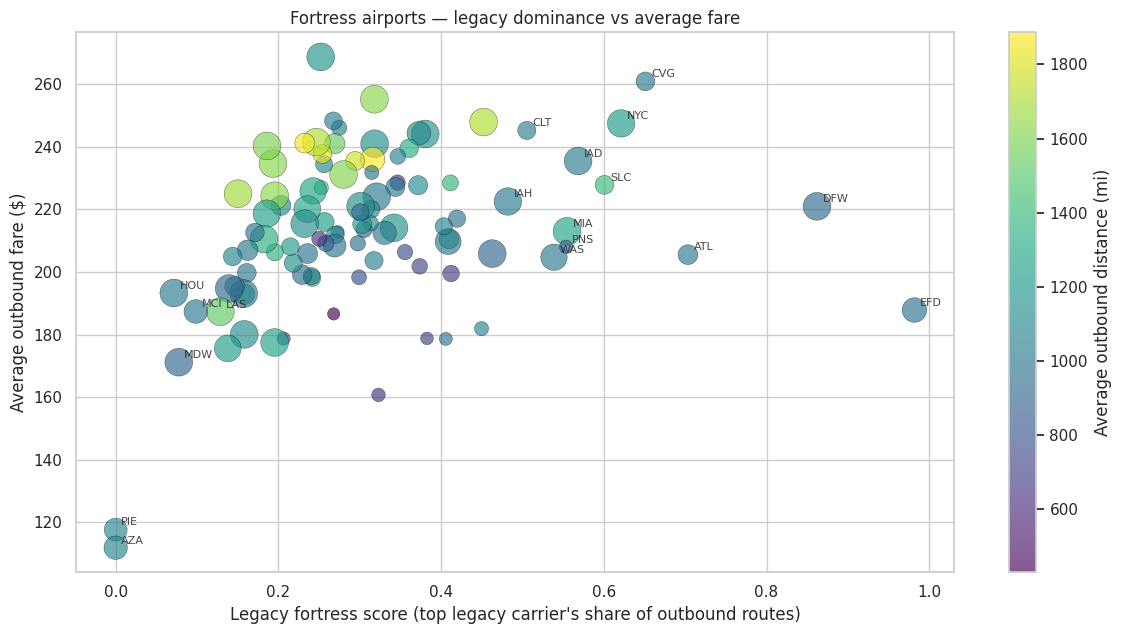

In [ ]:
# Scatter: fortress score (x) vs average outbound fare (y), sized by degree
fig, ax = plt.subplots(figsize=(12, 6.5))
sc = ax.scatter(busy["legacy_fortress_score"], busy["avg_fare"],
                s=np.clip(busy["degree"]*4, 20, 400), alpha=0.65,
                c=busy["avg_distance"], cmap="viridis",
                edgecolor="black", linewidth=0.3)
plt.colorbar(sc, label="Average outbound distance (mi)")

# Label the top fortresses and most competitive busy hubs
to_label = pd.concat([busy.nlargest(12, "legacy_fortress_score"),
                      busy.nsmallest(6, "legacy_fortress_score")])
for _, r in to_label.iterrows():
    ax.annotate(r["airport"], (r["legacy_fortress_score"], r["avg_fare"]),
                fontsize=8, alpha=0.85, xytext=(4, 3), textcoords="offset points")

ax.set_xlabel("Legacy fortress score (top legacy carrier's share of outbound routes)")
ax.set_ylabel("Average outbound fare ($)")
ax.set_title("Fortress airports — legacy dominance vs average fare")
plt.tight_layout(); plt.show()

In [ ]:
# Fortress airports vs rest of the country — distance-controlled fare difference
# using a simple airport-level regression. Each airport is one observation.
reg_ap = busy.copy()
reg_ap["high_fortress"] = (reg_ap["legacy_fortress_score"] >= 0.40).astype(int)

m_ap = smf.ols("avg_fare ~ avg_distance + high_fortress", data=reg_ap).fit()
print("=== Airport-level regression: avg_fare ~ distance + high_fortress (≥40% legacy share) ===")
print(f"n airports : {int(m_ap.nobs)}")
print(f"R²         : {m_ap.rsquared:.3f}")
b = m_ap.params["high_fortress"]
lo, hi = m_ap.conf_int().loc["high_fortress"].tolist()
print(f"high_fortress β = ${b:+.2f}  (95% CI ${lo:+.2f} to ${hi:+.2f})  "
      f"p = {m_ap.pvalues['high_fortress']:.4f}")
print()
# For contrast: what do the two groups look like on raw means?
print(reg_ap.groupby("high_fortress")
              .agg(n=("airport", "size"),
                   mean_fare=("avg_fare", "mean"),
                   mean_distance=("avg_distance", "mean"))
              .round(2))

=== Airport-level regression: avg_fare ~ distance + high_fortress (≥40% legacy share) ===
n airports : 102
R²         : 0.177
high_fortress β = $+7.39  (95% CI $-3.76 to $+18.54)  p = 0.1914

                n  mean_fare  mean_distance
high_fortress                              
0              80    212.150      1,152.830
1              22    217.010      1,084.970


### Airport-Level Fare Test

Next, I test whether high-fortress airports have higher average outbound fares after controlling for average distance.

The estimated effect is positive: high-fortress airports have average fares about **$7.39 higher** than other airports.

However, this result is **not statistically significant** at the usual threshold.

This means I should be careful. The direction supports the fortress-hub idea, but the airport-level regression alone is not strong enough to prove it. One reason is that the regression only has about **102 airport-level observations**, so it has much less data than the route-level models.

Still, the ranking itself is meaningful because it identifies recognizable legacy hubs and gives a better structural explanation than simple route-level monopoly.

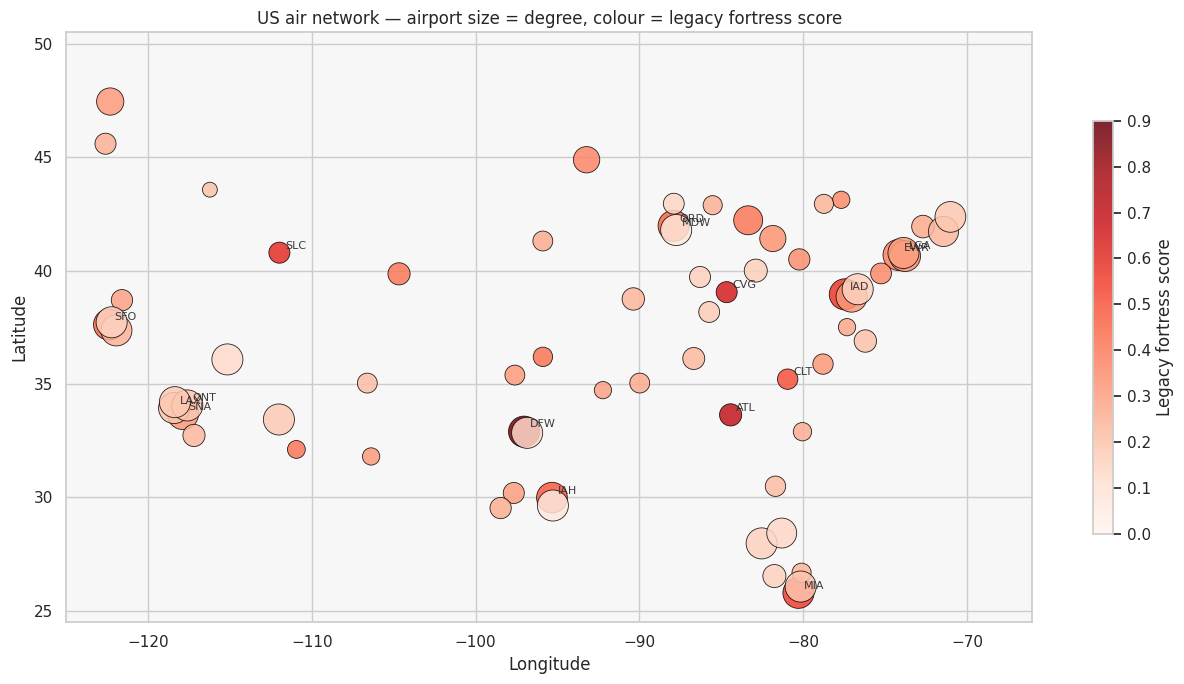

Mapped 69 of 102 airports (remaining are small airports not in the top-US coordinate lookup).


In [ ]:
# --- US map of fortress hubs -----------------------------------------
# Use a hardcoded lookup for the top US airports' coordinates (public, widely cited).
# This avoids the 39k missing geocoded rows in the source data.

AIRPORT_COORDS = {
    "ATL": (33.6407, -84.4277), "DFW": (32.8998, -97.0403),
    "ORD": (41.9742, -87.9073), "LAX": (33.9416, -118.4085),
    "DEN": (39.8561, -104.6737), "JFK": (40.6413, -73.7781),
    "SFO": (37.6213, -122.3790), "SEA": (47.4502, -122.3088),
    "LAS": (36.0840, -115.1537), "MCO": (28.4312, -81.3081),
    "EWR": (40.6895, -74.1745), "CLT": (35.2140, -80.9431),
    "PHX": (33.4373, -112.0078), "IAH": (29.9902, -95.3368),
    "MIA": (25.7959, -80.2870), "BOS": (42.3656, -71.0096),
    "MSP": (44.8848, -93.2223), "FLL": (26.0742, -80.1506),
    "DTW": (42.2162, -83.3554), "PHL": (39.8744, -75.2424),
    "LGA": (40.7769, -73.8740), "BWI": (39.1774, -76.6684),
    "SLC": (40.7884, -111.9778), "IAD": (38.9531, -77.4565),
    "DCA": (38.8512, -77.0402), "MDW": (41.7868, -87.7522),
    "SAN": (32.7338, -117.1933), "TPA": (27.9755, -82.5332),
    "HNL": (21.3187, -157.9225), "PDX": (45.5898, -122.5951),
    "STL": (38.7487, -90.3700), "BNA": (36.1245, -86.6782),
    "AUS": (30.1975, -97.6664), "HOU": (29.6454, -95.2789),
    "DAL": (32.8481, -96.8512), "SJC": (37.3626, -121.9290),
    "OAK": (37.7213, -122.2207), "RDU": (35.8776, -78.7875),
    "MEM": (35.0424, -89.9767), "CLE": (41.4117, -81.8498),
    "CVG": (39.0489, -84.6678), "MKE": (42.9472, -87.8966),
    "CMH": (39.9980, -82.8919), "IND": (39.7173, -86.2944),
    "PIT": (40.4915, -80.2329), "SNA": (33.6757, -117.8682),
    "SMF": (38.6951, -121.5908), "SAT": (29.5337, -98.4698),
    "RSW": (26.5362, -81.7552), "PBI": (26.6832, -80.0956),
    "JAX": (30.4941, -81.6879), "ONT": (34.0560, -117.6012),
    "ANC": (61.1743, -149.9963), "ABQ": (35.0402, -106.6091),
    "TUS": (32.1161, -110.9411), "BUF": (42.9404, -78.7322),
    "OMA": (41.3032, -95.8941), "OKC": (35.3931, -97.6007),
    "BDL": (41.9389, -72.6832), "ELP": (31.8072, -106.3776),
    "TUL": (36.1983, -95.8881), "BUR": (34.2007, -118.3587),
    "PVD": (41.7240, -71.4282), "GRR": (42.8808, -85.5228),
    "ROC": (43.1189, -77.6724), "RIC": (37.5052, -77.3197),
    "SDF": (38.1744, -85.7360), "ORF": (36.8946, -76.2012),
    "JAX": (30.4941, -81.6879), "CHS": (32.8986, -80.0405),
    "ONT": (34.0560, -117.6012), "LIT": (34.7294, -92.2244),
    "BIL": (45.8077, -108.5428), "BOI": (43.5644, -116.2228),
    "JAC": (43.6073, -110.7377),  # Jackson WY (from the hook)
}

fig, ax = plt.subplots(figsize=(13, 7))

# Plot state-level outline (simple bounding box and a neutral background)
ax.set_facecolor("#f7f7f7")
ax.set_xlim(-125, -66)
ax.set_ylim(24.5, 50.5)

# Plot airports
mapped = airport_df[airport_df["airport"].isin(AIRPORT_COORDS)]
xs = [AIRPORT_COORDS[a][1] for a in mapped["airport"]]
ys = [AIRPORT_COORDS[a][0] for a in mapped["airport"]]
sc = ax.scatter(xs, ys,
                s=np.clip(mapped["degree"]*5, 30, 500),
                c=mapped["legacy_fortress_score"],
                cmap="Reds", vmin=0, vmax=0.9,
                edgecolor="black", linewidth=0.6, alpha=0.85)
plt.colorbar(sc, ax=ax, shrink=0.7, label="Legacy fortress score")

# Annotate top fortresses and largest mapped airports
to_label = pd.concat([
    mapped.nlargest(10, "legacy_fortress_score"),
    mapped.nlargest(8, "degree"),
]).drop_duplicates("airport")
for _, r in to_label.iterrows():
    if r["airport"] not in AIRPORT_COORDS: continue
    lat, lon = AIRPORT_COORDS[r["airport"]]
    ax.annotate(r["airport"], (lon, lat), fontsize=8, alpha=0.9,
                xytext=(4, 3), textcoords="offset points")

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("US air network — airport size = degree, colour = legacy fortress score")
plt.tight_layout(); plt.show()

print(f"Mapped {len(mapped)} of {len(airport_df)} airports (remaining are small "
      f"airports not in the top-US coordinate lookup).")

### Phase 7 Takeaway

This phase shows that airport-level dominance is a better way to think about legacy-carrier market power than simple route-level monopoly.

The graph-based fortress score successfully identifies well-known legacy hubs such as DFW, ATL, IAD, CLT, ORD, and SFO. That suggests the score captures a real airline-network structure.

The airport-level regression gives a positive fare effect, but it is not statistically strong enough to be the main proof by itself.

So the main value of this phase is that it reframes the project:

**The fare premium may not be spread evenly across all monopoly routes. It may be concentrated at legacy-dominated fortress airports.**

The next phases test this idea further using time trends and a concrete case study.

## Phase 8 - Has the Legacy Premium Changed Over Time?

In the earlier phases, the full-period route-level legacy monopoly effect was not very strong. But airline markets changed a lot over time, especially after major mergers.

So the question in this phase is:

**Has the legacy-carrier monopoly premium become stronger over time?**

This matters because several major mergers reshaped the U.S. airline industry:

- Delta and Northwest merged in 2008
- United and Continental merged in 2010
- American and US Airways merged in 2013

To compare fares fairly across years, I first adjust all fares to **2024 dollars** using CPI. Without this adjustment, an increase in fares over time could simply reflect inflation.

Then I re-run the monopoly regression year by year, only within legacy carriers, and track how the monopoly coefficient changes over time.

### Assumptions and Tradeoffs

- I use CPI adjustment so fares from different years are comparable in 2024 dollars.
- I focus only on legacy carriers because this phase is about legacy-market power.
- I interpret the merger dates as useful context, not as causal proof.
- Year-by-year regressions can be noisier than one pooled model, but they help reveal changes over time.

In [ ]:
# --- BLS CPI-U annual averages (base = 2024) -------------------------
CPI = {
    1993: 144.5, 1994: 148.2, 1995: 152.4, 1996: 156.9, 1997: 160.5,
    1998: 163.0, 1999: 166.6, 2000: 172.2, 2001: 177.1, 2002: 179.9,
    2003: 184.0, 2004: 188.9, 2005: 195.3, 2006: 201.6, 2007: 207.3,
    2008: 215.3, 2009: 214.5, 2010: 218.1, 2011: 224.9, 2012: 229.6,
    2013: 233.0, 2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1,
    2018: 251.1, 2019: 255.7, 2020: 258.8, 2021: 271.0, 2022: 292.7,
    2023: 304.7, 2024: 313.7,
}
BASE = CPI[2024]

# Convert nominal fares to 2024 dollars
df["fare_2024"] = df["fare"] * (BASE / df["year"].map(CPI))

# Build a temporal regression frame (reusing reg + carrier type)
reg_t = reg.copy()
reg_t["carrier_type_lg"] = df.loc[reg_t.index, "carrier_type_lg"]
reg_t["fare_2024"]       = df.loc[reg_t.index, "fare_2024"]

# Sanity check — fares should scale up by more in older years
print("CPI adjustment sanity check (mean fare nominal vs 2024$):")
_chk = reg_t.groupby("year")[["fare", "fare_2024"]].mean().round(2)
print(_chk.head(3))
print("…")
print(_chk.tail(3))

CPI adjustment sanity check (mean fare nominal vs 2024$):
        fare  fare_2024
year                   
1993 212.660    461.660
1994 216.130    457.500
1996 199.280    398.430
…
        fare  fare_2024
year                   
2022 248.170    265.970
2023 248.750    256.090
2024 255.180    255.180


### CPI Adjustment Check

The CPI adjustment converts older nominal fares into 2024-dollar values.

This is important because a fare from the 1990s cannot be directly compared to a fare from 2024 without accounting for inflation.

The sanity check shows that older fares become larger after adjustment, while 2024 fares remain unchanged. This confirms that the adjustment is working as expected.

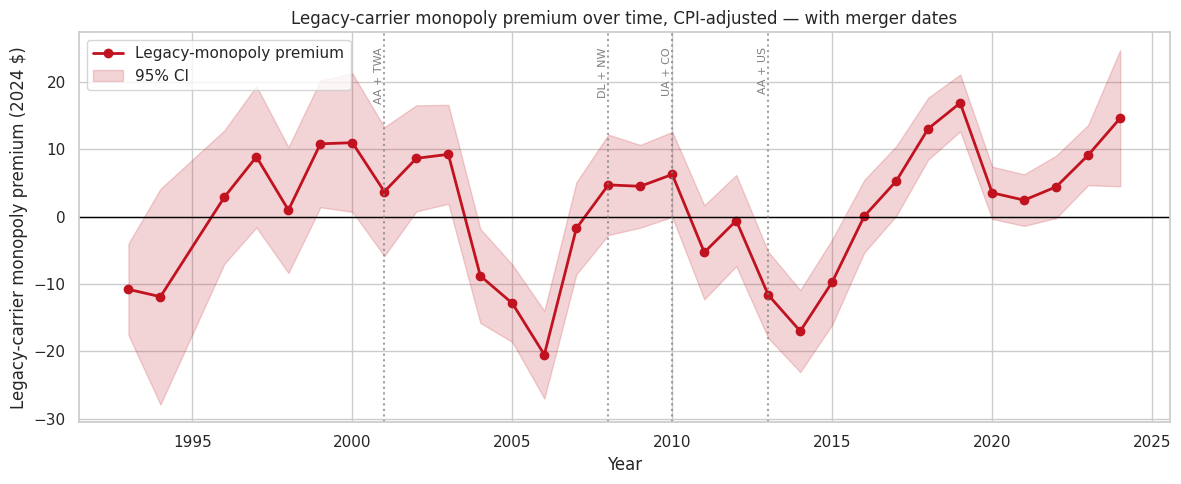

,year,n,premium_2024$,lo,hi
21,2015,4679,-9.680,-16.020,-3.350
22,2016,4762,0.080,-5.320,5.470
23,2017,4670,5.300,0.130,10.470
24,2018,4668,13.090,8.490,17.690
25,2019,4758,16.900,12.680,21.110
26,2020,4246,3.560,-0.320,7.430
27,2021,4301,2.470,-1.360,6.300
28,2022,4093,4.450,-0.180,9.080
29,2023,3971,9.160,4.680,13.630
30,2024,1002,14.640,4.520,24.760


In [ ]:
# Year-by-year M4 on Legacy carriers, 2024-dollar fare
year_rows = []
for yr, sub in reg_t[reg_t["carrier_type_lg"] == "Legacy"].groupby("year"):
    if sub["is_monopoly"].nunique() < 2 or len(sub) < 300:
        continue
    m = smf.ols(
        "fare_2024 ~ nsmiles + log_passengers + C(quarter_c) "
        "+ is_monopoly + carrier_overlap",
        data=sub,
    ).fit()
    lo, hi = m.conf_int().loc["is_monopoly"].tolist()
    year_rows.append({
        "year":    int(yr),
        "n":       int(m.nobs),
        "premium_2024$": m.params["is_monopoly"],
        "lo":      lo,
        "hi":      hi,
    })
year_legacy = pd.DataFrame(year_rows)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(year_legacy["year"], year_legacy["premium_2024$"], marker="o",
        color="#c1121f", lw=2, label="Legacy-monopoly premium")
ax.fill_between(year_legacy["year"], year_legacy["lo"], year_legacy["hi"],
                alpha=0.18, color="#c1121f", label="95% CI")
ax.axhline(0, color="black", lw=1)

# Merger annotations
mergers = [(2008, "DL + NW"), (2010, "UA + CO"), (2013, "AA + US"),
           (2001, "AA + TWA")]
for y, txt in mergers:
    if year_legacy["year"].min() <= y <= year_legacy["year"].max():
        ax.axvline(y, color="gray", ls=":", alpha=0.75)
        ax.text(y, ax.get_ylim()[1]*0.92, txt, rotation=90, fontsize=8,
                ha="right", va="top", color="gray")

ax.set_xlabel("Year")
ax.set_ylabel("Legacy-carrier monopoly premium (2024 $)")
ax.set_title("Legacy-carrier monopoly premium over time, CPI-adjusted — with merger dates")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

year_legacy.tail(10).round(2)

### Time Trend Result

The legacy-carrier monopoly premium changes noticeably over time.

Before the mid-2010s, the estimated premium is often negative or close to zero. But after around **2016–2017**, the coefficient becomes positive and more meaningful.

For example:

- **2017:** about **+ 5.30 dollars**
- **2018:** about **+ 13.09 dollars**
- **2019:** about **+ 16.90 dollars**
- **2023:** about **+ 9.16 dollars**
- **2024:** about **+ 14.64 dollars**

There is also a drop around the COVID period, which makes sense because airline demand and pricing were heavily disrupted during that time.

Overall, the pattern suggests that the legacy monopoly premium may have become more visible after the major merger integrations were completed.

### Phase 8 Takeaway

This phase adds a time dimension to the project.

The full-period average can hide important changes over time. When I look year by year, the legacy-carrier monopoly premium appears weak or negative in earlier years, but becomes more positive after the mid-2010s.

This does not prove that mergers caused the premium to grow. The analysis is observational, and other factors may also contribute. However, the timing is meaningful because the positive shift appears after the major legacy-carrier merger period.

So the main takeaway is:

**The legacy monopoly premium is not constant over time. It appears more visible in the post-consolidation period.**

The next phase turns this into a concrete case study by comparing a legacy fortress airport with a more low-cost-oriented airport.

## Phase 9 - Case Study: DFW vs MDW

After the graph analysis, I use a concrete case study to make the fortress-hub idea easier to understand.

The question here is:

**How different are fares from a legacy fortress airport compared to a more competitive airport, when both serve the same destinations?**

I compare:

- **DFW (Dallas/Fort Worth)** as a legacy fortress hub dominated by American Airlines
- **MDW (Chicago Midway)** as a lower-fortress, Southwest-dominated comparison airport

This comparison is useful because both airports are large enough to have many shared destinations, but they represent very different market structures.

### Assumptions and Tradeoffs

- I compare only destinations served by both airports to make the comparison fairer.
- I require enough observations at both airports before including a destination.
- This is still not a causal estimate because DFW and MDW may differ in traveler mix, business demand, airport costs, and carrier strategy.
- The goal is to create an understandable real-world comparison, not to prove the exact dollar impact for every passenger.

In [ ]:
# --- Pick the pair ----------------------------------------------------
# We hand-pick the case study rather than take the algorithmic top/bottom,
# for two reasons:
#   1. The algorithm would pick whichever airports happen to sit at the
#      extremes of `legacy_fortress_score`, which can be small secondary
#      fields even after the size filter.
#   2. We need two airports that are *comparable in scale* and
#      *both familiar*, so the per-ticket gap is interpretable.
#
# DFW (Dallas/Fort Worth) — classic legacy fortress (American's largest hub).
# MDW (Chicago Midway)    — classic Southwest-dominated low-cost hub,
#                           serving a similar national network.
# Both are large (degree ≥ 40, tens of thousands of quarter-observations)
# and share many destinations, so the per-destination comparison is fair.

f_ap = "DFW"
c_ap = "MDW"

fortress    = airport_df[airport_df["airport"] == f_ap].iloc[0]
competitive = airport_df[airport_df["airport"] == c_ap].iloc[0]

print(f"Fortress hub     : {fortress['airport']}  "
      f"(top legacy carrier = {fortress['top_legacy']}, "
      f"fortress_score = {fortress['legacy_fortress_score']:.2f}, "
      f"avg fare ${fortress['avg_fare']:.0f}, degree {int(fortress['degree'])}, "
      f"n_obs {int(fortress['n_obs']):,})")
print(f"Competitive hub  : {competitive['airport']}  "
      f"(top legacy carrier = {competitive['top_legacy']}, "
      f"fortress_score = {competitive['legacy_fortress_score']:.2f}, "
      f"avg fare ${competitive['avg_fare']:.0f}, degree {int(competitive['degree'])}, "
      f"n_obs {int(competitive['n_obs']):,})")

# Overlap destinations
f_dests = set(df[df["airport_1"] == f_ap]["airport_2"]) | set(df[df["airport_2"] == f_ap]["airport_1"])
c_dests = set(df[df["airport_1"] == c_ap]["airport_2"]) | set(df[df["airport_2"] == c_ap]["airport_1"])
overlap = (f_dests & c_dests) - {f_ap, c_ap}
print(f"Common destinations between {f_ap} and {c_ap}: {len(overlap)}")

Fortress hub     : DFW  (top legacy carrier = AA, fortress_score = 0.86, avg fare $221, degree 129, n_obs 10,187)
Competitive hub  : MDW  (top legacy carrier = DL, fortress_score = 0.08, avg fare $171, degree 124, n_obs 9,758)
Common destinations between DFW and MDW: 106


In [ ]:
# --- Build the paired-destination comparison table --------------------
def avg_fare_from(origin, dest):
    m = ((df["airport_1"] == origin) & (df["airport_2"] == dest)) | \
        ((df["airport_1"] == dest)   & (df["airport_2"] == origin))
    if m.sum() == 0:
        return np.nan, np.nan, np.nan
    sub = df.loc[m]
    return sub["fare"].mean(), sub["nsmiles"].mean(), len(sub)

rows = []
for d in sorted(overlap):
    f_fare, dist, f_n = avg_fare_from(f_ap, d)
    c_fare, _,    c_n = avg_fare_from(c_ap, d)
    if pd.notna(f_fare) and pd.notna(c_fare) and f_n >= 4 and c_n >= 4:
        rows.append({
            "destination":             d,
            "distance (mi)":           int(dist),
            f"fare from {f_ap} ($)":   round(f_fare, 2),
            f"fare from {c_ap} ($)":   round(c_fare, 2),
            "gap ($)":                 round(f_fare - c_fare, 2),
        })

case_table = pd.DataFrame(rows).sort_values("gap ($)", ascending=False)
print(f"Destinations with enough observations at both hubs: {len(case_table)}")
print()
print("=== Largest fare gaps (fortress premium per destination) ===")
print(case_table.head(15).to_string(index=False))
print()
print(f"Mean gap across shared destinations: ${case_table['gap ($)'].mean():.2f}")
print(f"Median gap                           : ${case_table['gap ($)'].median():.2f}")
print(f"Fraction of destinations where fortress is more expensive: "
      f"{(case_table['gap ($)'] > 0).mean():.1%}")

Destinations with enough observations at both hubs: 89

=== Largest fare gaps (fortress premium per destination) ===
destination  distance (mi)  fare from DFW ($)  fare from MDW ($)  gap ($)
        CLE           1023            268.990            117.870  151.120
        LGA           1427            290.700            144.220  146.480
        GRR            931            269.720            124.200  145.510
        IND            761            231.630             92.580  139.050
        BOS           1562            279.450            143.490  135.960
        MHT           1562            301.630            167.080  134.560
        EWR           1427            290.730            161.330  129.400
        ISP           1428            285.260            156.300  128.960
        DCA           1217            273.990            146.930  127.050
        BDL           1471            314.710            190.660  124.050
        CMH            926            239.490            117.470  122

### Case Study Result

The comparison includes **89 shared destinations** with enough observations from both airports.

Across these shared destinations:

- The average fare gap is about **56.71 dollars**
- The median fare gap is about **55.29 dollars**
- DFW is more expensive than MDW for about **86.5%** of shared destinations

This means the difference is not driven by just one or two unusual routes. In most shared destinations, the fortress airport has higher average fares.

In [ ]:
# --- Annual dollar transfer estimate ---------------------------------
# Order-of-magnitude: mean per-ticket fare gap × true annual passenger volume
# touching the fortress airport.  We use the sum of 'passengers' across every
# route-quarter that touches the fortress airport, divided by the number of
# distinct years in the panel — this gives a genuine passengers-per-year number
# rather than the mean × routes back-of-envelope that double-counted earlier.

mean_gap = case_table["gap ($)"].mean()

f_mask          = (df["airport_1"] == f_ap) | (df["airport_2"] == f_ap)
total_passengers = df.loc[f_mask, "passengers"].sum()
n_years          = df["year"].nunique()
annual_pax_est   = total_passengers / n_years

impact_m = mean_gap * annual_pax_est / 1e6

print(f"Rough annual aggregate impact at {f_ap}:")
print(f"  mean fare gap            : ${mean_gap:.2f}")
print(f"  total passengers in panel: {total_passengers:,.0f}  (across {n_years} years)")
print(f"  ≈ passengers per year    : {annual_pax_est:,.0f}")
print(f"  ≈ ${impact_m:,.1f} million per year transferred to the dominant carrier,")
print(f"    relative to what a competitive hub charges on the same routes.")
print()
print("NOTE: this is an order-of-magnitude estimate — the fare gap is conditioned "
      "on destination overlap, not a causal fare difference, and the passenger "
      "count averages across the 32-year panel.  Treat as a headline, not a "
      "precise number.")

Rough annual aggregate impact at DFW:
  mean fare gap            : $56.71
  total passengers in panel: 5,279,210  (across 31 years)
  ≈ passengers per year    : 170,297
  ≈ $9.7 million per year transferred to the dominant carrier,
    relative to what a competitive hub charges on the same routes.

NOTE: this is an order-of-magnitude estimate — the fare gap is conditioned on destination overlap, not a causal fare difference, and the passenger count averages across the 32-year panel.  Treat as a headline, not a precise number.


### Rough Impact Estimate

Using the average fare gap and estimated annual passenger volume touching DFW, the rough aggregate impact is about **$9.7 million per year** in the sampled data.

This number should be treated only as an order-of-magnitude estimate. It is not a precise causal estimate because the fare gap may also include differences in passenger mix, airport type, travel purpose, and airline service quality.

Still, it helps translate the fare gap into a more practical scale.

### Phase 9 Takeaway

This case study makes the fortress-hub pattern more concrete.

The earlier airport-level regression showed only a weak aggregate result, but the DFW vs MDW comparison shows a clear and understandable fare difference on shared destinations.

On average, flying from DFW costs about **$57 more** than flying from MDW to the same destination, and DFW is more expensive on about **86.5%** of shared destinations.

This does not prove that airport dominance alone causes the entire fare gap. However, it supports the broader story that passengers at legacy-dominated fortress hubs may face higher fares than passengers at more competitive or low-cost-oriented airports.

## Phase 10 - Takeaways

This project started with a simple question:
**Do we pay more when one airline dominates a route or airport?**

After going through all the analysis, here are the key takeaways.


### Finding 1 - Route-level monopoly does NOT increase fares

At the route level, the expected “monopoly premium” does not appear.

- After controlling for distance, demand, and time:
  - Monopoly routes are **not more expensive**
  - In many cases, they are actually **cheaper**
- This happens because many monopoly routes are operated by **low-cost carriers (ULCCs)**

So, route-level concentration (like 'large_ms ≥ 0.9') is **not a good measure of pricing power** — it mostly reflects *who operates the route*, not true market power.



### Finding 2 - The premium appears at the AIRPORT (hub) level

When we shift from routes to airports, a clearer pattern emerges.

- The **DFW vs MDW case study** shows:
  - ~**$56–$57 higher fares** from the fortress hub (DFW)
  - ~**86.5% of shared destinations** are more expensive from DFW

This suggests that pricing power is not about a single route,  
but about **control of an airport network (hub dominance)**.


### Finding 3 - The premium is a POST-2015 phenomenon

The time analysis shows a very clear pattern:

- **Before ~2015** → no consistent premium
- **After ~2016–2017** → premium becomes positive and grows
- By recent years → ~**$10–$15 higher fares (CPI-adjusted)**

This aligns with airline consolidation (Delta–NW, United–Continental, AA–US Airways),  
but the effect shows up **after integration is complete**, not immediately.


### Final Insight

The key insight from this project is:

- Monopoly pricing in airlines is not about "one airline on one route."  
- It is about **who controls the airport and the network around it.**


### Consumer Perspective

You are not overpaying just because there’s only one airline on a route - you may be overpaying because that airline dominates the airport.


### Policy Perspective

- Route-level competition metrics can be misleading  
- Airport-level dominance (hub control) matters more  
- The effects of consolidation may show up **with a delay**, not immediately


## Limitations

To keep the analysis honest, here are the key limitations:

1. **Aggregate data (not ticket-level)**
   - We use route averages, not individual ticket prices  
   - Cannot fully capture business vs leisure pricing differences

2. **Carrier type simplification**
   - Airlines are grouped into Legacy / ULCC / Regional  
   - Differences within groups (e.g., AA vs DL) are not modeled

3. **Not causal**
   - Results show strong patterns, but not strict causation  
   - Especially for merger effects and airport pricing power

4. **Airport-level regression is weaker**
   - Only ~100 airports → limited statistical power  
   - Stronger evidence comes from the **case study (DFW vs MDW)**

5. **HHI approximation**
   - Uses only top carriers → may underestimate true competition structure


## Final Conclusion

- **Route-level monopoly ≠ higher prices**
- **Airport dominance (fortress hubs) = higher prices**
- **The effect grows over time after consolidation**

So yes,.. in many real-world cases,  
**you do pay more when an airline dominates the airport... not just the route.**

## Phase 11 - Appendix: What I tried and did not use

In this project, not every idea worked — and that’s important.

Instead of removing them, I briefly document the approaches I explored but chose not to include in the final analysis, along with why.


### 1. Naive 'monopoly -> higher price' hypothesis (Phases 2–4)

Initially, I tried to directly measure a **single monopoly premium**.

- Regression results showed a **negative or insignificant effect**
- This was surprising and did not match the intuition

Instead of ignoring it, I kept it — because this failure led to an important insight:
**route-level monopoly is confounded by carrier type (ULCC vs legacy)**

This is what motivated the shift to **carrier-type and airport-level analysis**.


### 2. K-Means clustering on routes

I tried clustering routes using features like:
- fare, distance, passengers, market share

What I found:
- Clusters existed, but were **not clearly separated**
- Groups mainly differed by **distance and volume**, not monopoly structure

This method did not directly help answer the pricing question,  
so I replaced it with **regression-based analysis**, which gave clearer insights.


### 3. Node2Vec embeddings (airports)

I experimented with graph embeddings to capture airport relationships.

- Embeddings captured **network structure well**
- But they did **not add clear value for explaining fares**

Since my goal was pricing (not network similarity),  
I did not include this in the final pipeline.


### 4. Alternative competition metrics

I tested other ways to measure competition:
- HHI (concentration index)
- entropy of carrier shares
- share gap between top carriers

What I found'
- All of them were **highly correlated with `large_ms'**
- They did **not add new information**

So I kept the simpler and more interpretable metrics: market_concentration and is_monopoly


### 5. Carrier-level fixed effects (not used)

I considered adding a dummy variable for each airline.

- This would better control for carrier differences
- But it would introduce **too many variables (60+ carriers)**

Instead, I used a simpler and more interpretable approach:
- Group carriers into **Legacy, ULCC, Regional**
- Then analyze within these groups

### 6. Difference-in-Differences for mergers (future work)

I explored the idea of using airline mergers (Delta–NW, United–Continental, AA–US) as a natural experiment.

- This could give a **causal estimate**
- But it requires detailed route-level pre/post tracking

Since this dataset was not structured for that,  
I used a **time-trend analysis instead (Phase 8)**


## Why this matters

These experiments helped validate the final results.

- The main findings are **not dependent on one method**
- Simpler models gave **more interpretable and consistent insights**
- The final approach was chosen because it best answered the question:
  **Does market structure affect prices? If yes, where and how?**

## Collaboration Declaration

### Collaborators
- None.

### Web Sources
- General documentation for Python libraries and methods/approaches used in the notebook.

### AI Tools
- Claude - used to explore possible approaches, understand the problem, assist with coding, debugging, and considering alternative methods.
- ChatGPT - used to help structure the notebook and improve clarity of explanations and markdown write-ups.